<a href="https://colab.research.google.com/github/MemoirePOC/PoC-Securite-et-performance-ATS-Niamey/blob/main/Notebook_PoC_SECURITE_PERFORMANCE_ATS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proof of Concept (PoC) pour l'analyse des données de surveillance du trafic aérien à des fins de sécurité et performance ATS : démonstration de la valeur opérationnelle d'un dataset de trajectoires aériennes pour l'ASECNA. Cas de l'espace aérien du Niger**





**Memoire pour l’obtention du diplôme d’Ingénieur de l’EAMAC**

**Spécialité** : Exploitation de l’aviation civile

**Dévoloppé par** :
* M. BATIMSOGA Sanbena

* Mlle BACKITA BOUSSAMBA Olivia

**Sous l’encadrement de** M. MOUSTAPHA Amadou Roufai, Chargé des systèmes de management sécurité, sûreté, qualité et environnement, ASECNA Bénin

##**Introduction**

Ce notebook nous permet de calculer des indicateurs de sécurité et de performance ATS à partir des données de surveillance ADS-B de Flightradar24, croisées avec les données reçues du centre ASECNA de Niamey : plan de vol FPL, les fichiers Billing, les filets de sauvegarde (STCA, MSAW) et les rapports d'événements de sécurité.

Limites géographiques de l'etude : **Espace aérien du Niger**

AIP ASECNA, partie ENR — UTA Niamey (FL245–FL460), TMA Niamey (FL145–FL245, 900M/Sol).

**Sources des seuils de séparation en guidage Radar : MANEX ASECNA, CCR Niamey**
- Séparation horizontale entre deux positions : **10 NM**
- Séparation horizontale entre a/c en montée ou en descente croisant le niveau d'au autre a/c stable derrière ce dernier : **5 NM**
- Séparation verticale RVSM : **1000 ft**
- Séparation verticale standard : **2000 ft**

**Source des performances aéronefs :** OpenAP — Open Aircraft Performance Modeling (Sun, Junzi. *Open Aircraft Performance Modeling Based on an Analysis of Aircraft Surveillance Data*. PhD Thesis, TU Delft, 2019). Le module WRAP fournit des enveloppes statistiques de performance dérivées de millions de trajectoires ADS-B réelles, plus représentatives que les valeurs constructeur théoriques.

**Source des émissions CO2.** OpenAP FuelFlow pour la consommation de carburant, facteur de conversion kérosène → CO2 = 3.16 (CORSIA).

---

## **Structure du Projet**

| Etape | Contenu |
|--------|---------|
| 1 | Configuration, imports et variables globales |
| 2 | Chargement des fichiers de données |
| 3 | Construction des secteurs de l'espace (TMA1, TMA2, UTA) |
| 4 | Netoyage et aperçu des données |
| 5 | Analyse éxploratoire des données ADS-B |
| 6 | Nettoyage et préparation |
| 7 | Filtrage géographique UTA + TMA |
| 8 | Indicateurs de sécurité ATS |
| 9 | Indicateurs de performance ATS  |

Le notebook est organisé en 15 modules :

1.  **Configuration & Fonctions (Modules 1-3)** : Installation des bibliothèques, définition des variables globales et construction géométrique des secteurs (TMA Niamey, UTA).
2.  **Traitement des Données (Modules 4-7)** : Nettoyage des identifiants, filtrage géographique et Analyse exploratoire.
3.  **Analyses de la Sécurité (Modules 8-12)**

4.  **Analyses de la Performance (Modules 13-15)**
---

## Tableau des indicateurs

| Code | Famille | Indicateur |
|------|---------|------------|
| Id1 | Sécurité | Minimum du taux de rapprochement entre aéronefs |
| *Id2* |*Sécurité* | *Taux de conformité au franchissement des obstacles* |
| Id3 | Sécurité | Taux d’alertes STCA pertinentes |
| Id4 | Sécurité | Écart temporel entre le déclenchement du STCA et la première manœuvre de résolution observée |
| Id5 | Sécurité | Qualité de l'alignement sur l'axe de piste à l'atterrissage |
| Id6 (KPI 05 - GANP) | Performance | Allongement effectif en route |
| Id7 (KPI 16 - GANP) | Performance | Consommation additionnelle de carburant |
| Id8  | Performance  | Émissions additionnelles de CO₂ avec et sans guidage radar |
---
Ces indicateurs sont accompagnés d'une estimation de leur incertitude conformément aux recommandations du Guide pour l'expression de l'incertitude de mesure (GUM). Une colonne de tolérance est ajoutée à chaque tableau afin de quantifier l'effet des erreurs de mesure sur les résultats obtenus.

Les hypothèses retenues sont les suivantes :

- Précision horizontale des positions ADS-B : **10 m**.
- Niveau de confiance : **95 %**.

L'incertitude sur une distance horizontale est calculée par propagation des erreurs :

$$\Delta d=\frac{p_r}{2.448}\sqrt{2}\,\Phi^{-1}(0.95)$$

avec :

- $p_r$ : précision horizontale de la mesure (10 m) ;
- $\Phi$ : fonction de répartition de la loi normale.

Pour les indicateurs exprimés sous forme de rapport ou de pourcentage $(R=\frac{norme}{D})$ , l'incertitude est obtenue par propagation selon :

$$\Delta R = R \times \frac{p_r}{D}$$

où :

- $R$ est la valeur de l'indicateur ;
- $D$ est la distance intervenant dans son calcul.

❌❌❌ **Le calcul de l'indicateur Id2 ( Taux de conformité au franchissement des obstacles ) a été abandonné à cause d'une limitation de fr24 à nous fournir le l'instant où le calage passe de 1013,25 hPa au QNH ou QFE.**

## **Guide d'exploration du Notebook (sur Github)**

Sur Github, vous pouvez passer à la lecture du notebook dans colab en cliquant sur le bouton `Open in Colab`  au début du notebook

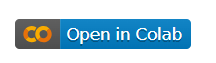

Une fois dans Colab, vous pouvez utiliser le bouton `Sommaire` pour naviguer rapidement dans le notebook et accéder directement au module souhaité, sans avoir à le faire défiler entièrement.

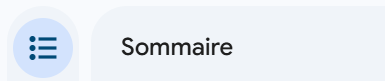

## **Module 1 — Configuration, imports et variables global**

### 1.1 Montage Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Les dépendances
C'est l'ensemble des bibliothèques ou paquets externes dont notre code a besoin pour s'exécuter correctement.

| Bibliothèque | Rôle |
|---|---|
| `traffic` | Manipulation des trajectoires ADS-B |
| `openap` | Performance aéronef et consommation carburant |
| `pandas`, `numpy`, `scipy` | Manipulation de données et statistiques |
| `folium`, `ipyleaflet` | Cartes interactives Leaflet |
| `plotly`, `matplotlib`, `seaborn` | Graphiques |
| `geopy` | Distances géodésiques |
| `shapely` | Géométrie 2D, test point-dans-polygone |
| `hvplot` | Graphiques interactifs |
| `kaleido` | Export d'images Plotly |
| `pywmm` | Conversion entre caps vrais et magnétiques |
| `nvector` | Géodésie sur l'ellipsoïde WGS84 |
| `pyproj` | Projection stéréographique |


In [2]:
!pip install -q scipy
!pip install -q folium
!pip install -q ipyleaflet
!pip install -q traffic
!pip install -q ipywidgets
!pip install -q plotly
!pip install -q hvplot
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q geopy
!pip install -q shapely
!pip install -q tqdm
!pip install -q kaleido
!pip install -q openap
!pip install -q pywmm
!pip install -q pydeck
!pip install -q meteostat
!pip install -q nvector
!pip install -q  numpy==2.0.2
!pip install -q  pandas==2.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.3/28.3 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.9/204.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8

### 1.3 Les imports





In [3]:
import pandas, numpy
print("PANDAS:", pandas.__version__, "NUMPY:", numpy.__version__)

PANDAS: 2.2.2 NUMPY: 2.0.2


In [4]:
import pandas as pd
import numpy as np
import math
import os
import re

import requests
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime, timedelta
from pathlib import Path
from glob import glob

from pywmm import WMMv2
from geopy.distance import great_circle, geodesic
import nvector as nv

# Bibliothèque traffic
from traffic.core import Traffic, Flight
from traffic.data import navaids

# Géométrie
from shapely.geometry import Point
from shapely.geometry import Polygon as SPolygon

# Cartographie interactive
from ipyleaflet import (Map, LayersControl, CircleMarker, LayerGroup,
                         Marker, Polyline, AwesomeIcon, Popup, DivIcon)
from ipyleaflet import Polygon as LPolygon
from ipywidgets import HTML, Layout

# Graphiques
import hvplot.pandas
import hvplot
import plotly.graph_objects as go

# Performance aéronef
import openap
from openap import WRAP, FuelFlow, prop

# Projection
from pyproj import Proj, Geod

# Affichage
from IPython.display import display, HTML as DHTML, Markdown

print('Imports chargés avec succès.')

Imports chargés avec succès.


### 1.4 Configuration de l'affichage
Cette cellule configure l'environnement de travail avant le lancement des traitements. Elle réalise les opérations suivantes :

- configure l'affichage des DataFrame `pandas` en augmentant le nombre de colonnes visibles, la largeur d'affichage et le format des nombres décimaux ;
- configure `NumPy` pour afficher les valeurs numériques avec une précision de quatre décimales et sans notation scientifique ;


In [5]:
# Configuration pandas
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuration numpy
np.set_printoptions(precision=4, suppress=True)

### 1.5 Variables globales

In [6]:
NM_TO_M  = 1852.0
FT_TO_M  = 0.3048
GEOD = Geod(ellps="WGS84")

# ─── Projection stéréographique TopSky — SYSTEM_CENTRE Niamey ───────────

proj_niamey = Proj( proj='stere', lat_0=16.25, lon_0=3.495833,
                   k_0=1.0, x_0=0, y_0=0, ellps='WGS84')

# ─────────── Données de DRRN ───────────────────────────────────────────
ALT_TRANS = 3800
LARGEUR    = 45 #300 CHANGEMENT DE LA VARIABLE LARGERUR DE LA PISTE
RITAT    = (13.47378, 2.00136)     # IAF/IF
RN501     = (13.47731, 2.07697)     # FAF/FAP
THR09R   = (13.48161, 2.16941)     # seuil 09R
VAR      = -1.0                    # declinaison Niamey 1 W (AIP DRRN)
BRG_TRUE = 88.0 + VAR              # Orientation vrai de l'axe 09R = 87.0
R_T      = 6371000.0               # rayon Terre (m)

# --- Référentiel pour le franchissement des obstacles DRRN

df_obstacles = pd.DataFrame([
    {   "Seuil": "09R", "nom": "NDB NY", "lat": 13.480972, "lon": 2.156528,"alt_ft": 715,
     "dist_der_m": 2784, "MFO_DEP_ft": 0.008*2784/0.3048, "MFO_ARR_ft": 75/0.3048, "D_seuil_m": 3084},

    {   "Seuil": "27L", "nom": "VOR/DME", "lat": 13.481500, "lon": 2.198500,"alt_ft": 722,
     "dist_der_m": 190, "MFO_DEP_ft": 0.008*190/0.3048, "MFO_ARR_ft": 75/0.3048,"D_seuil_m": 390}])

# ─── Chemins des fichiers de données ─────────────────────────────────────
PATH             = 'drive/MyDrive/DATASET_POC/'
FICHIER_STCA     = PATH + 'STCA_AVRIL_2026.xlsx'
FICHIER_MSAW     = PATH + 'MSAW_AVRIL_2026.xlsx'
FPL_DIR          = PATH + 'FPL/'
BILLING_DIR      = PATH + 'Billing_Avril_2026/'

PATH_FR24        = PATH + 'FR24API/'
TMA_GENERAL_DIR  = PATH_FR24 + '1_TMA_GENERALE/'
APPROCHE_DIR     = PATH_FR24 + '2_APPROCHE_FINALE/'
RMG_DIR          = PATH_FR24 + '3_REMISE_DE_GAZ/'
AIRPROX_DIR      = PATH_FR24 + '4_AIRPROX/'
STCA1_DIR        = PATH_FR24 + '5_STCA/STCA1/'
STCA2_DIR        = PATH_FR24 + '5_STCA/STCA2/'
STCA3_DIR        = PATH_FR24 + '5_STCA/STCA3/'
DEP_DIR          = PATH_FR24 + '6_DEPART/'
AIRPROX_120s_DIR = PATH_FR24 + '7_AIRPROX_120s/'
TMA_GENERAL_DIR2 = PATH_FR24 + '8_TMA_GENERALE/'
TMA_GENERAL_DIR3 = PATH_FR24 + 'TMA_GENERALE0804/'
TMA_GENERAL_DIR4 = PATH_FR24 + 'TMA_GENERALE0904/'
STCA_SSR_DIR     = PATH_FR24 + 'STCA_SSR/'

# ─── Obstacles d'aérodrome DRRN ──────────────────────────────────────────
Obstacles        = PATH + 'obstacles_drrn.csv'

# ─── Paramètres carte ────────────────────────────────────────────────────
col_id        = 'icao24'
col_type      = 'type'

# ─── CO2 ─────────────────────────────────────────────────────────────────
FACTEUR_CO2   = 3.16   # Jet A1 : Annexe 16 Volume IV, CORSIA. OACI

print('Variables globales chargées.')

Variables globales chargées.


### 1.6 Fonctions du notebook

#### 1.6.1 Fonctions utilitaires d'affichage

In [7]:
def afficher_html(titre, style='titre'):
    styles = {
        'titre':      'color:#1F4E79;font-size:18px;font-weight:bold;border-bottom:2px solid #1F4E79;padding-bottom:4px;',
        'sous_titre': 'color:#2E5F8A;font-size:14px;font-weight:bold;margin-top:8px;',
        'succes':     'color:#1976D2;font-weight:bold;',
        'erreur':     'color:red;font-weight:bold;',
        'defaut':     'color:orange;font-weight:bold;',
    }
    display(DHTML(f'<p style="{styles.get(style,"")}">{titre}</p>'))

#### 1.6.2 Fonctions géométriques — Construction des espaces aériens

In [8]:
def dms(d, m, s):
    return d + m/60 + s/3600


def centre_arc(p_start, p_end, rayon_nm, cote='gauche'):
    lat_avg = (p_start[0] + p_end[0]) / 2
    cos_lat = math.cos(math.radians(lat_avg))
    dx = (p_end[1] - p_start[1]) * 60 * cos_lat
    dy = (p_end[0] - p_start[0]) * 60
    chord = math.hypot(dx, dy)
    if chord > 2 * rayon_nm:
        raise ValueError("Corde trop longue")
    d_val = math.sqrt(rayon_nm**2 - (chord/2)**2)
    ux, uy = dx/chord, dy/chord
    if cote == 'droite':
        px, py = uy, -ux
    else:
        px, py = -uy, ux
    cx = dx/2 + d_val * px
    cy = dy/2 + d_val * py
    lat_c = p_start[0] + cy / 60
    lon_c = p_start[1] + cx / (60 * cos_lat)
    return (lat_c, lon_c)


def arc_polyline(centre, p_start, p_end, rayon_nm=60, n=30, direction='ccw'):
    lat_c, lon_c = centre
    cos_lat = math.cos(math.radians(lat_c))

    def angle(p):
        dx = (p[1] - lon_c) * 60 * cos_lat
        dy = (p[0] - lat_c) * 60
        return math.atan2(dy, dx)

    a1 = angle(p_start)
    a2 = angle(p_end)
    if direction == 'ccw':
        while a2 < a1:
            a2 += 2 * math.pi
    else:
        while a2 > a1:
            a2 -= 2 * math.pi

    points = []
    for i in range(n + 1):
        t = i / n
        a = a1 + (a2 - a1) * t
        dx = rayon_nm * math.cos(a)
        dy = rayon_nm * math.sin(a)
        points.append((lat_c + dy/60, lon_c + dx/(60*cos_lat)))
    return points


def interpoler(p_a, p_b, n=10):
    return [(p_a[0] + (p_b[0]-p_a[0])*(i/n),
             p_a[1] + (p_b[1]-p_a[1])*(i/n)) for i in range(1, n)]


def construire_cercle(lat, lon, rayon_nm, n=120):
    R = 6371
    r = rayon_nm * 1.852
    pts = []
    for i in range(n):
        a = 2 * math.pi * i / n
        dlat = (r / R) * math.cos(a)
        dlon = (r / R) * math.sin(a) / math.cos(math.radians(lat))
        pts.append((lat + math.degrees(dlat), lon + math.degrees(dlon)))
    pts.append(pts[0])
    return pts

#### 1.6.3 Fonctions de construction des espaces aériens

In [9]:
def construire_polygone_tma1():
    """TMA1 Niamey — cercle de 80 NM autour de DRRN (VOR/DME NY)."""
    NY = (dms(13, 29, 0), dms(2, 12, 23))
    coords = construire_cercle(NY[0], NY[1], 80)
    poly = SPolygon([(lon, lat) for lat, lon in coords])
    return coords, {"NY": NY}, {"NY": NY}, poly


def construire_polygone_tma2():
    """TMA2 Niamey — polygone défini par l'AIP ASECNA."""
    sommets = {
        'P1': (dms(15,14,12),    dms(0,3,0)),
        'P2': (dms(16,14,16.29), -dms(0,1,35.40)),
        'P3': (dms(16,15,18),    dms(1,0,48)),
        'P4': (dms(16,15,0),     dms(4,35,0)),
        'P5': (dms(13,43,39.24), dms(4,35,0.41)),
        'P6': (dms(11,0,38.28),  dms(3,45,6.37)),
        'P7': (dms(11,0,0),      -dms(0,29,0)),
        'P8': (dms(12,21,0),     -dms(0,29,0)),
    }
    BAKAB = centre_arc(sommets['P1'], sommets['P2'], 60, 'gauche')
    OG    = (dms(12,20,46.6), -dms(1,30,46.2))
    arc1  = arc_polyline(BAKAB, sommets['P1'], sommets['P2'])
    arc2  = arc_polyline(OG,    sommets['P8'], sommets['P1'])
    frontiere = interpoler(sommets['P5'], sommets['P6'])
    contour = (arc1
               + [sommets['P3'], sommets['P4'], sommets['P5']]
               + frontiere
               + [sommets['P6'], sommets['P7'], sommets['P8']]
               + arc2
               + [sommets['P1']])
    poly = SPolygon([(lon, lat) for lat, lon in contour])
    return contour, sommets, {"BAKAB": BAKAB, "OG": OG}, poly


def construire_polygone_uta():
    """UTA Niamey — même contour que TMA2 (FL245–FL460)."""
    return construire_polygone_tma2()


ESPACES = {
    "TMA1": (construire_polygone_tma1, "blue"),
    "TMA2": (construire_polygone_tma2, "green"),
    "UTA":  (construire_polygone_uta,  "red"),
}

#### 1.6.4 Fonctions de cartographie

In [10]:
def creer_carte(contour, couleur="red", nom="Zone", zoom=7):
    centre_lat = sum(p[0] for p in contour) / len(contour)
    centre_lon = sum(p[1] for p in contour) / len(contour)
    m = Map(center=(centre_lat, centre_lon), zoom=zoom,
            layout=Layout(width="100%", height="600px"))
    layer = LPolygon(locations=contour, color=couleur,
                     fill_color=couleur, fill_opacity=0.3, name=nom)
    m.add_layer(layer)
    m.add_control(LayersControl())
    return m, layer


def afficher_zone(nom):
    nom = nom.upper()
    if nom not in ESPACES:
        raise ValueError(f"Zone inconnue : {list(ESPACES.keys())}")
    func, couleur = ESPACES[nom]
    contour, sommets, centres, poly = func()
    carte, _ = creer_carte(contour, couleur, nom)
    display(carte)
    return carte, contour, poly, sommets, centres


def afficher_toutes_zones():
    """Affiche TMA1 (bleu), TMA2 (vert) et UTA (rouge) sur une même carte."""
    carte = Map(center=(14.5, 0), zoom=7,
                layout=Layout(width="100%", height="600px"))
    carte.add_control(LayersControl())
    for nom, (func, couleur) in ESPACES.items():
        contour, _, _, _ = func()
        carte.add_layer(LPolygon(
            locations=contour, color=couleur,
            fill_color=couleur, fill_opacity=0.25, name=nom))
    return carte

def creer_carte_base(zoom=7):
    centre = (sum(p[0] for p in contour_uta) / len(contour_uta),
              sum(p[1] for p in contour_uta) / len(contour_uta))
    m = Map(center=centre, zoom=zoom, layout=Layout(width='100%', height='600px'))
    m.add(LPolygon(locations=contour_uta, color='royalblue',
                   fill_color='royalblue', fill_opacity=0.05, fill=False, name='UTA'))
    return m

def couleur_vol(groupe):
    dest = groupe['dest_icao'].iloc[0]
    orig = groupe['orig_icao'].iloc[0]
    if dest == 'DRRN':
        return 'yellow'   # arrivée
    elif orig == 'DRRN':
        return 'orange'   # départ
    else:
        return 'blue'     # survol

from ipyleaflet import Polyline
from ipywidgets import HTML

def ajouter_trajectoires_sur_carte(existing_map, df, col_id='callsign'):
    """Ajoute les trajectoires d'un DataFrame à une carte ipyleaflet existante."""
    for cs, groupe in df.groupby(col_id):
        groupe = groupe.sort_values('timestamp')
        coords = list(zip(groupe['latitude'], groupe['longitude']))
        couleur = couleur_vol(groupe)
        existing_map.add_layer(Polyline(locations=coords, color=couleur, weight=2, fill=False))
    return existing_map

def trac_trajectoires(traffic_obj, callsigns, zoom=8):
    m = creer_carte_base(zoom)  # carte fraîche à chaque appel

    PALETTE = [
              '#e74c3c', '#2980b9', '#27ae60', '#f39c12', '#8e44ad',
              '#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
              '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabebe',
              '#469990', '#e6beff', '#9A6324', '#fffac8', '#800000']

    for cs, color in zip(callsigns, PALETTE):
        df = traffic_obj.data.query("callsign == @cs").sort_values("timestamp")
        coords = list(zip(df['latitude'], df['longitude']))
        m.add(Polyline(locations=coords, color=color, weight=3, opacity=0.9, fill=False, name=cs))
        icon = DivIcon(
            html=f'<div style="color:{color};font-weight:bold;background:white;'
                 f'padding:1px 5px;border-left:3px solid {color};font-size:12px">{cs}</div>',
            icon_size=(80, 22), icon_anchor=(0, 11)
        )
        m.add(Marker(location=coords[-1], icon=icon, draggable=False))

    return m

#### 1.6.5 Fonctions de chargement des données

In [11]:
def charger_fpl(fpl_dir):
    """Charge l'ensemble des fichiers FPL (.tsv) d'un dossier."""
    fpl_files = sorted(glob(os.path.join(fpl_dir, "*.tsv")))
    if not fpl_files:
        raise FileNotFoundError(f"Aucun fichier .tsv trouvé dans {fpl_dir}")
    header = pd.read_csv(fpl_files[0], sep="\t", skiprows=3,
                          nrows=0, encoding="latin1").columns.tolist()
    liste_df = []
    for fichier in fpl_files:
        df = pd.read_csv(fichier, sep="\t", skiprows=4, header=None,
                          names=header, encoding="latin1", low_memory=False)
        df["Fichier"] = os.path.basename(fichier)
        liste_df.append(df)
    return pd.concat(liste_df, ignore_index=True)

FIELDS_BILLING = [
    ('Callsign',       0,   9),
    ('REG',            9,  20),
    ('Type',          20,  25),
    ('Origine',       25,  30),
    ('Destination',   30,  35),
    ('Règle de vol',  35,  37),
    ('Statut',        37,  39),
    ('Operation_Type',39,  43),
    ('Billing_Type',  43,  57),
    ('Date',          57,  65),
    ('Number_Count',  65,  71),
    ('Position1',     71,  83),
    ('Time1',         83,  88),
    ('Position2',     88, 100),
    ('Time2',        100, 104),
]

def lire_fichiers_billing(billing_dir):
    """Lit et concatène les fichiers Billing (.bill) d'un dossier."""
    fichiers = sorted(glob(billing_dir + "*.bill"))
    lignes = []
    for fichier in fichiers:
        with open(fichier, "r", encoding="utf-8", errors="ignore") as f:
            for ligne in f:
                if ligne.strip():
                    lignes.append({nom: ligne[debut:fin].strip()
                                    for nom, debut, fin in FIELDS_BILLING})
    return pd.DataFrame(lignes)

def charger_donnees(path):
    """Charge un fichier CSV, Excel, JSON ou Parquet et retourne un DataFrame"""

    if not os.path.exists(path):
        print(f"NOTFOUND  {os.path.basename(path)}  (fichier introuvable)")
        return None

    try:
        if path.endswith(".csv"):
            df = pd.read_csv(path)
        elif path.endswith((".xlsx", ".xls")):
            df = pd.read_excel(path)
        elif path.endswith(".json"):
            df = pd.read_json(path)
        elif path.endswith(".parquet"):
            df = pd.read_parquet(path)
        else:
            print(f"ECHEC  {os.path.basename(path)}  (format non pris en charge)")
            return None
    except Exception as e:
        # Fichier present mais illisible (vide, corrompu, mauvais encodage)
        print(f"ECHEC  {os.path.basename(path)}  ({type(e).__name__})")

        return None

    # Conversion automatique de toute colonne contenant "timestamp" ou "date"
    for col in df.columns:
        if 'timestamp' in col.lower() or 'date' in col.lower():
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

   # print(f"OK  {os.path.basename(path)}  ({len(df)} lignes x {df.shape[1]} colonnes)\n {'='*70}\n")
    return df


def charger_dossier_concatener(chemin, parse_dates=None, tri_naturel=True, verbose=True):
    """
    Charge et concatène tous les fichiers CSV d'un dossier.
    Tri naturel actif par défaut (tranche1 < tranche2 < ... < tranche8).
    """
    fichiers = glob(os.path.join(chemin, '*.csv'))

    if not fichiers:
        raise FileNotFoundError(f'Aucun fichier CSV trouvé dans : {chemin}')

    if tri_naturel:
        def _cle(p):
            return [int(t) if t.isdigit() else t.lower()
                    for t in re.split(r'(\d+)', os.path.basename(p))]
        fichiers = sorted(fichiers, key=_cle)
    else:
        fichiers = sorted(fichiers)

    dfs = []
    for f in fichiers:
        try:
            df = pd.read_csv(f, parse_dates=parse_dates or False, low_memory=False)
            df['_source'] = os.path.basename(f)
            dfs.append(df)
           # if verbose:
            #    print(f'  OK  {os.path.basename(f)}  ({len(df):,} lignes)')
        except Exception as e:
            print(f'  [AVERT] {os.path.basename(f)} ignoré : {e}')

    df_out = pd.concat(dfs, ignore_index=True)

   # if verbose:
    #    print(f'\n  Total : {len(fichiers)} fichier(s) — {df_out.shape[0]:,} lignes × {df_out.shape[1]} colonnes\n {"="*70}\n')

    return df_out

#### 1.6.6 Fonctions de nettoyage et préparation ADS-B

In [12]:
def nettoyer_identifiants(df: pd.DataFrame, label: str = 'Dataset') -> pd.DataFrame:

    def est_vide(serie):
        return serie.isna() | (serie.astype(str).str.strip() == '')

    def tableau_etape(etape, description, avant, apres):
        display(pd.DataFrame({
            'Étape'          : [etape],
            'Opération'      : [description],
            'Lignes avant'   : [f'{avant:,}'],
            'Lignes supprimées': [f'{avant - apres:,}'],
            'Lignes restantes': [f'{apres:,}'],
        }))

    afficher_html(f'Nettoyage des identifiants — {label}', style='titre')

    # ── Étape 1 : doublons exacts ─────────────────────────────────────────
    afficher_html('Étape 1 — Suppression des doublons exacts', style='sous_titre')
    avant = len(df)
    df = df.drop_duplicates()
    tableau_etape(1, 'Lignes entièrement identiques supprimées', avant, len(df))

    # ── Étape 2 : lignes sans callsign ET sans flight ─────────────────────
    afficher_html('Étape 2 — Lignes sans callsign ET sans flight', style='sous_titre')
    avant = len(df)
    masque_incomplet = est_vide(df['callsign']) & est_vide(df['flight'])

    df_ok        = df[~masque_incomplet].copy()
    df_incomplet = df[masque_incomplet].copy()

    # Table de référence : fr24_id → callsign/flight depuis les lignes valides
    ref = (
        df_ok
        .groupby('fr24_id', as_index=False)
        .agg(callsign_ref=('callsign', 'first'),
             flight_ref   =('flight',  'first'))
    )

    df_incomplet = df_incomplet.merge(ref, on='fr24_id', how='left')
    recuperables = df_incomplet['callsign_ref'].notna() | df_incomplet['flight_ref'].notna()

    df_recupere = df_incomplet[recuperables].copy()
    df_recupere['callsign'] = df_recupere['callsign_ref'].fillna(df_recupere['callsign'])
    df_recupere['flight']   = df_recupere['flight_ref'].fillna(df_recupere['flight'])
    df_recupere = df_recupere.drop(columns=['callsign_ref', 'flight_ref'])

    n_recuperees = recuperables.sum()
    n_supprimees = (~recuperables).sum()

    display(pd.DataFrame({
        'Catégorie'        : ['Sans callsign & flight', 'fr24_id récupérable', 'fr24_id orphelin'],
        'Lignes'           : [f'{masque_incomplet.sum():,}',
                              f'{n_recuperees:,}',
                              f'{n_supprimees:,}'],
        'Action'           : ['détectées', 'callsign/flight récupéré', 'supprimées'],
    }))

    # ── Bilan final ───────────────────────────────────────────────────────
    df_final = pd.concat([df_ok, df_recupere], ignore_index=True)

    afficher_html('Bilan global', style='sous_titre')
    display(pd.DataFrame({
        'Indicateur' : ['Lignes initiales', 'Doublons exacts', 'Orphelins supprimés', 'Lignes finales'],
        'Valeur'     : [f'{avant:,}',
                        f'{avant - len(df_ok) - masque_incomplet.sum():,}',
                        f'{n_supprimees:,}',
                        f'{len(df_final):,}'],
    }))
    # Renommer lat et lon
    return df_final.rename(columns={'lat': 'latitude','fr24_id' : 'icao24', 'lon': 'longitude','alt': 'altitude'})

def nettoyer_positions_altitudes(df, alt_min=0, alt_max=65000):
    """Supprime les positions géographiques invalides et les altitudes aberrantes."""
    n0 = len(df)
    df = df[df['latitude'].between(-90, 90) & df['longitude'].between(-180, 180)].copy()
    n1 = len(df)
    df = df[df['altitude'].between(alt_min, alt_max)].copy()
    n2 = len(df)
    print(f"Positions invalides : {n0 - n1}")
    print(f"Altitudes aberrantes : {n1 - n2}")
    print(f"Points conserves : {n2:,} ({n2/n0*100:.1f} %)")
    return df

def filtrer_d(df_clean, contour):
    """Filtre les points ADS-B dans la bounding box puis dans le polygone UTA."""
    lats = [p[0] for p in contour]
    lons = [p[1] for p in contour]
    bbox = df_clean[
        df_clean['latitude'].between(min(lats), max(lats)) &
        df_clean['longitude'].between(min(lons), max(lons))
    ].copy()
    print(f"Filtre bbox    : {len(df_clean)-len(bbox)} points écartés")
    poly = SPolygon([(lon, lat) for lat, lon in contour_uta])
    mask = bbox.apply(lambda r: poly.contains(Point(r['longitude'], r['latitude'])), axis=1)
    df_uta = bbox[mask].copy()
    print(f"Filtre polygone : {(~mask).sum()} points écartés")
    print(f"Points dans UTA : {len(df_uta)}")
    return df_uta, poly

#### 1.6.7 Fonctions MSAW et Billing

In [13]:
def plot_msaw_zones(df):
    """Graphique de répartition des callsigns selon le niveau d'alertes MSAW."""
    df = df.sort_values("Nombre_alertes", ascending=True)
    callsigns = df["Aircraft Callsign"]
    values    = df["Nombre_alertes"]
    plt.figure(figsize=(10, 8))
    plt.axvspan(0,  5,              color="green",  alpha=0.2)
    plt.axvspan(5,  10,             color="orange", alpha=0.2)
    plt.axvspan(10, max(values.max(), 10), color="red", alpha=0.2)
    plt.scatter(values, callsigns)
    plt.xlabel("Nombre d'alertes MSAW")
    plt.ylabel("Aircraft Callsign")
    plt.title("Répartition des 15 premiers Callsign selon le niveau de risque MSAW")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

#### 1.6.8 Equipements de surveillance

In [14]:
def analyse_ssr_adsb(FPL):
    """
    I1 / I2 — Taux d'emport SSR et ADS-B OUT depuis la case 10b des FPL OACI.
    La case 10b est extraite entre le 2e '/' et le '-' qui suit.
    """
    equip10b = (FPL["Texte"]
                .str.extract(r'^(?:[^/]+/){2}([^-]+)-', expand=False)
                .fillna(""))
    n = len(FPL)
    statut = pd.DataFrame({
        "SSR_MODE_A":    equip10b.str.contains("A",  regex=False).sum() / n,
        "SSR_MODE_C":    equip10b.str.contains("C",  regex=False).sum() / n,
        "SSR_S_CODE_S":  equip10b.str.contains("S",  regex=False).sum() / n,
        "SSR_S_CODE_E":  equip10b.str.contains("E",  regex=False).sum() / n,
        "SSR_S_CODE_H":  equip10b.str.contains("H",  regex=False).sum() / n,
        "SSR_S_CODE_I":  equip10b.str.contains("I",  regex=False).sum() / n,
        "SSR_S_CODE_L":  equip10b.str.contains("L",  regex=False).sum() / n,
        "SSR_S_CODE_P":  equip10b.str.contains("P",  regex=False).sum() / n,
        "SSR_S_CODE_X":  equip10b.str.contains("X",  regex=False).sum() / n,
        "ADSB_CODE_B1":  equip10b.str.contains("B1", regex=False).sum() / n,
        "ADSB_CODE_B2":  equip10b.str.contains("B2", regex=False).sum() / n,
        "ADSB_CODE_U1":  equip10b.str.contains("U1", regex=False).sum() / n,
        "ADSB_CODE_U2":  equip10b.str.contains("U2", regex=False).sum() / n,
        "ADSB_CODE_V1":  equip10b.str.contains("V1", regex=False).sum() / n,
        "ADSB_CODE_V2":  equip10b.str.contains("V2", regex=False).sum() / n,
    }, index=["TAUX"]).T
    return statut.sort_values("TAUX", ascending=False)

In [15]:
def taux_equipement(FPL):
    """
    Taux de vols equipes SSR, ADS-B, les deux, ou aucun des deux,
    a partir de la case 10b des FPL OACI.
    """
    equip10b = (FPL["Texte"]
                .str.extract(r'^(?:[^/]+/){2}([^-]+)-', expand=False)
                .fillna(""))

    codes_ssr = ["A", "C", "S", "E", "H", "I", "L", "P", "X"]
    codes_adsb = ["B1", "B2", "U1", "U2", "V1", "V2"]

    ssr_ok = pd.concat([equip10b.str.contains(c, regex=False) for c in codes_ssr], axis=1).any(axis=1)
    adsb_ok = pd.concat([equip10b.str.contains(c, regex=False) for c in codes_adsb], axis=1).any(axis=1)

    n = len(FPL)
    taux = pd.Series({
        "SSR_SEUL":     (ssr_ok & ~adsb_ok).sum() / n,
        "ADSB_SEUL":    (adsb_ok & ~ssr_ok).sum() / n,
        "SSR_ET_ADSB":  (ssr_ok & adsb_ok).sum() / n,
        "AUCUN_DES_DEUX": (~ssr_ok & ~adsb_ok).sum() / n,
        "SSR_TOTAL":    ssr_ok.sum() / n,
        "ADSB_TOTAL":   adsb_ok.sum() / n,
    }, name="TAUX")

    return taux.to_frame()

#### 1.6.9 Fonction de profils vertical et horizontal

In [16]:
def profil_vertical_temps(traffic_obj, id_avion_1, id_avion_2, label='', altitude_range=None):
    """Trace les profils d'altitude de deux aeronefs.
    Au survol de chaque courbe : callsign, heure UTC et altitude.

    altitude_range : tuple optionnel (ymin, ymax) pour fixer l'echelle
    de l'axe des altitudes, par exemple (3500, 3700).
    """

    if hasattr(id_avion_1, 'callsign'):
        id_avion_1 = id_avion_1.callsign
    if hasattr(id_avion_2, 'callsign'):
        id_avion_2 = id_avion_2.callsign

    afficher_html(f'Evolution verticale dans le temps - {id_avion_1} vs {id_avion_2}  |  {label}', style='titre')

    df = traffic_obj.data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')

    vol1 = df[df['callsign'] == id_avion_1].sort_values('timestamp')
    vol2 = df[df['callsign'] == id_avion_2].sort_values('timestamp')

    if vol1.empty or vol2.empty:
        afficher_html('Un des deux identifiants est introuvable dans le dataset.', style='erreur')
        return

    hover = ('<b>%{fullData.name}</b><br>'
             'Heure : %{x|%H:%M:%S} UTC<br>'
             'Altitude : %{y:,.0f} ft'
             '<extra></extra>')

    fig = go.Figure()
    fig.add_trace(go.Scatter( x=vol1['timestamp'], y=vol1['altitude'],
        mode='lines+markers', name=id_avion_1, line=dict(width=2), marker=dict(size=4),
        hovertemplate=hover))
    fig.add_trace(go.Scatter(
        x=vol2['timestamp'], y=vol2['altitude'], mode='lines+markers', name=id_avion_2,
        line=dict(width=2), marker=dict(size=4), hovertemplate=hover))

    fig.update_layout(
        title=f"{id_avion_1} vs {id_avion_2} - Profils d'altitude",
        xaxis_title='Temps (UTC)', yaxis_title='Altitude (ft)',
        hovermode='closest',  height=450,
        legend=dict(orientation='h', y=1.08))

    if altitude_range is not None:
        fig.update_yaxes(range=altitude_range)

    fig.show()

In [17]:
def profil_vertical_distance(df, callsigns, label="callsign"):

    if isinstance(callsigns, str): callsigns = [callsigns]
    p = None
    for cs in callsigns:
        g = df[df.callsign.eq(cs)].sort_values("timestamp")
        c = g.hvplot.line(x="cumdist", y="altitude",
                          hover_cols=["timestamp","latitude","longitude","flight"])\
             .relabel(g[label].iat[0])
        p = c if p is None else p * c

    return p.opts(title="Évolution verticale par rapport à la distance", xlabel="Distance", ylabel="Altitude (ft)")

#-----------------------------------------------------------------------------------------
def profil_horizontal_temps(traffic_obj, id_avion_1, id_avion_2, label=''):
    """Evolution de la distance horizontale entre deux aéronefs."""

    if hasattr(id_avion_1, 'callsign'):
        id_avion_1 = id_avion_1.callsign
    if hasattr(id_avion_2, 'callsign'):
        id_avion_2 = id_avion_2.callsign

    afficher_html(f"Evolution du rapprochement horizontal - {id_avion_1} vs {id_avion_2} | {label}",
        style="titre")
    df = traffic_obj.data.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    vol1 = (df[df.callsign == id_avion_1].sort_values("timestamp").set_index("timestamp"))
    vol2 = ( df[df.callsign == id_avion_2].sort_values("timestamp").set_index("timestamp"))

    if vol1.empty or vol2.empty:
        afficher_html("Un des deux vols est introuvable.", style="erreur")
        return

    # Synchronisation temporelle
    commun = vol1.join(vol2, how="inner", lsuffix="_1",rsuffix="_2")

    if commun.empty:
        afficher_html("Aucun instant commun.", style="erreur")
        return

    # Distance géodésique
    _, _, distance = GEOD.inv(commun["longitude_1"].values,
        commun["latitude_1"].values,  commun["longitude_2"].values,
        commun["latitude_2"].values)

    commun["distance_nm"] = distance / 1852
    hover = (
        "<b>%{x|%H:%M:%S}</b><br>"
        "Distance horizontale : %{y:.2f} NM"
        "<extra></extra>"
    )

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=commun.index,
            y=commun["distance_nm"], mode="lines+markers",
            name="Ecart horizontal", hovertemplate=hover))

    fig.add_hline(y=5,line_dash="dash", annotation_text="5 NM" )

    fig.update_layout(title=f"{id_avion_1} vs {id_avion_2} - Ecart horizontal",
        xaxis_title="Temps (UTC)", yaxis_title="Ecart horizontal (NM)",
        hovermode="closest", height=450)
    fig.show()

#-----------------------------------------------------------------------
def sens_deux_routes(traffic_obj):#Determiner si les avions sont sur
    vols = list(traffic_obj)      # - la même route,
    f1, f2 = vols[0], vols[1]     # - des routes convergentes
                                  # - en sens inverses. Cela est utile pour le controle aux procédures
    t1 = f1.data['track'].median()
    t2 = f2.data['track'].median()

    diff = abs(t1 - t2) % 360

    if diff < 45 or diff > 315:
        type_route = "Même route"
    elif 45 <= diff <= 135 or 225 <= diff <= 315:
        type_route = "Routes convergentes"
    else:
        type_route = "Routes en sens inverse"

    print(f"{f1.callsign} → {t1:.1f}°  |  {f2.callsign} → {t2:.1f}°")
    print(f"Angle : {diff:.1f}°  →  {type_route}")

#### 1.6.10 Fonction Id1- Minimum des taux de rapprochement des aéronefs

In [18]:
def serie_Tr(df, sh_nm=10.0, sv_ft=1000.0,
                        alt_min_ft=1000.0): #  alt_min_ft=1000.0 pour les aéronefs en vols à 1000ft au moins.
    """Serie des Tr(i,j) pour chaque couple d'aéronefs."""

    sync = Traffic(df.query('altitude >= @alt_min_ft'))

    tab = (sync.closest_point_of_approach(lateral_separation=20*1852, #20NM et 2000ft, modifiables au besoin, sont mis pour eviter que la methode ne nous
                                          vertical_separation=2000).data)  #renvoie un dataframe vide en cas de non rapprochement 10NM,1000ft.
                                                                            #Notre objectif est de capté beaucoup point et de pouvoir réutiliser la fonction pour
    tab = (tab[tab['icao24_x'] < tab['icao24_y']]                           # la dectection automatique des STCA en captant des situation latentes
           .rename(columns={                                                #Un second filtre sera imposer dans l'application.
               'icao24_x':'icao24_i',
               'callsign_x':'aeronef_i',
               'icao24_y':'icao24_j',
               'callsign_y':'aeronef_j'
           }))

    tab["Trh"] = tab["lateral"] / sh_nm
    tab["Trv"] = tab["vertical"] / sv_ft
    tab["Tr"]  = tab[["Trh","Trv"]].max(axis=1)

    cols = ['timestamp','icao24_i','aeronef_i',
            'icao24_j','aeronef_j',
            'lateral','vertical',
            'Trh','Trv','Tr']

    return tab[cols].sort_values(
        ['icao24_i','icao24_j','timestamp']
    ).reset_index(drop=True)

#------------------------------------------------------------------
def tab_Tr(df, **kwargs):
    """Une ligne par couple correspondant au minimum de Tr."""

    serie = serie_Tr(df, **kwargs)

    return (serie.sort_values("Tr")
                 .drop_duplicates(
                     subset=["icao24_i","icao24_j"],
                     keep="first")
                 .reset_index(drop=True))

#--------------------------------------------------------------------------------------
def conclusion_id1(Id1,tab_paires, sh_nm=10.0, sv_ft=1000.0):
    afficher_html(f"Minima de séparation appliquables pour l'étude : Horizontal = {sh_nm:g} NM, Vertical = {sv_ft:g} ft (MANEX)", style='sous_titre')

    if Id1 < 1:
        afficher_html( f"Id1 = {Id1:.3f} < 1 : au moins une perte de séparation détectée sur la periode considérée : analyse requise.",style='erreur')
        paires_infrac = tab_paires[tab_paires['Tr'] < 1]
        display(paires_infrac)
    else:
        afficher_html(f"Id1 = {Id1:.3f} ≥ 1 : minima de séparation respectés sur la période considérée",style='succes' )
        display(tab_paires.head(5))

####1.6.11 Fonctions Id2.Taux de franchissement d'obstacles

In [19]:
def detecter_dep_arr(df, alt_transition=ALT_TRANS, cle="icao24"):
    dep = df[(df.orig_icao=="DRRN") & (df.altitude<=alt_transition)].sort_values([cle,"timestamp"])
    arr = df[(df.dest_icao=="DRRN") & (df.altitude<=alt_transition)].sort_values([cle,"timestamp"])

    # Départs : dernier point au sol s'il existe
    dep0 = dep[dep.altitude==0].groupby(cle).tail(1)
    dep = pd.concat([dep[dep.altitude>0], dep0]).sort_values([cle,"timestamp"])

    # Arrivées : premier point au sol s'il existe
    arr0 = arr[arr.altitude==0].groupby(cle).head(1)
    arr = pd.concat([arr[arr.altitude>0], arr0]).sort_values([cle,"timestamp"])

    dep["phase"] = "DEP"
    arr["phase"] = "ARR"

    return pd.concat([dep, arr], ignore_index=True)
#----------------------------------------------------------------------------
THR = {"09R": (13.481611, 2.169414), "27L": (13.483233, 2.204500)}

QFU = {"09R": 87, "27L": 267}

def ecart_cap(a, b):
    return abs((a - b + 180) % 360 - 180)

def detecter_piste(df, cle="icao24", tol=30):
    out = []

    for _, g in df.groupby(cle):
        g = g.sort_values("timestamp").copy()
        p = g.iloc[0] if g.phase.iat[0] == "DEP" else g.iloc[-1]

        piste = None
        for r, (lat, lon) in THR.items():
            if ecart_cap(p.track, QFU[r]) <= tol:
                piste = r
                break

        g["piste"] = piste
        out.append(g)

    return pd.concat(out, ignore_index=True)
#-----------------------------------------------------------------
import meteostat as ms

def ajouter_qnh(df, station="61052", coeff_ft_par_hpa=28.0):
    df = df.copy()

    df = df.drop(columns=["QNH", "QNH_estime", "altitude_qnh"], errors="ignore")

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    debut = df["timestamp"].min().floor("h").tz_convert(None)
    fin = df["timestamp"].max().ceil("h").tz_convert(None)

    brutes = ms.hourly(station, debut, fin).fetch()

    if brutes.empty or "pres" not in brutes.columns:
        # Aucune donnee disponible pour la station et la periode demandees.
        df["QNH"] = 1013.25
        df["QNH_estime"] = True
        df["altitude_qnh"] = df["altitude"] + (df["QNH"] - 1013.25) * coeff_ft_par_hpa
        return df

    qnh = (brutes.reset_index()[["time", "pres"]].rename(columns={"time": "timestamp", "pres": "QNH"}))
    qnh["timestamp"] = pd.to_datetime(qnh["timestamp"]).dt.tz_localize("UTC")

    df = pd.merge_asof(  df.sort_values("timestamp"), qnh.sort_values("timestamp"),
                        on="timestamp",direction="nearest",)

    df["QNH_estime"] = df["QNH"].isna()
    df["QNH"] = df["QNH"].fillna(1013.25)

    df["altitude_qnh"] = df["altitude"] + (df["QNH"] - 1013.25) * coeff_ft_par_hpa

    return df
#------------------------------------------------------------------------------------
def d_protection_pans_ops(D):
    D = min(max(D, 60), 12660)
    return 300 + 2 * (D - 60) * math.tan(math.radians(15))

def calcul_id2(df, df_obstacles):

    doublons = df_obstacles["Seuil"][df_obstacles["Seuil"].duplicated()].unique()
    if len(doublons) > 0:
        raise ValueError(f"Seuils en double dans df_obstacles : {list(doublons)}")

    obs = {r.Seuil: r for _, r in df_obstacles.iterrows()}
    pistes_valides = {"09R", "27L"}

    def obstacle(l):
        if l.piste not in pistes_valides:
            raise ValueError(f"Piste inattendue : {l.piste!r} (attendu 09R ou 27L)")
        if l.phase == "DEP":           # obstacle du seuil oppose
            return obs["27L"] if l.piste == "09R" else obs["09R"]
        else:
            return obs["09R"] if l.piste == "09R" else obs["27L"]

    df = df.copy()
    df["date_vol"] = pd.to_datetime(df["timestamp"]).dt.date
    df["heure_vol"] = pd.to_datetime(df["timestamp"]).dt.time

    lignes = []

    for _, l in df.iterrows():

        o = obstacle(l)

        dh = GEOD.inv(l.longitude, l.latitude, o.lon, o.lat)[2]
        dv = l.altitude_qnh - o.alt_ft
        mfo = o.MFO_DEP_ft if l.phase == "DEP" else o.MFO_ARR_ft

        lignes.append([
            l.date_vol, l.heure_vol, l.icao24, l.callsign, l.phase, l.piste,
            o.nom, dh, dv, mfo, o.D_protection_m
        ])

    pts = pd.DataFrame(lignes, columns=[
        "date_vol", "heure_vol", "icao24", "callsign", "phase", "piste",
        "obstacle", "dh_m", "dv_ft", "mfo_ft", "d_protection_m"
    ])

    res = (pts.sort_values("dh_m")
              .groupby(["icao24", "date_vol"], as_index=False)
              .first())

    res["Txv"] = res["dv_ft"] / res["mfo_ft"]
    res["Txh"] = res["dh_m"] / res["d_protection_m"]
    res["Tx"] = res[["Txv", "Txh"]].max(axis=1)

    return res[[
        "date_vol", "heure_vol", "icao24", "callsign", "phase", "piste",
        "obstacle", "dh_m", "dv_ft", "Txh", "Txv", "Tx"
    ]]


#### 1.6.12 Fonctions Id3 - Pertinence des alertes STCA

In [20]:
def extrapoler_points(traj, t0, tolerance='10s', horizon='120s', freq='10s'):
    traj = traj.sort_values('timestamp').drop_duplicates('timestamp')
    e = traj.loc[(traj['timestamp'] - t0).abs().idxmin()]
    if abs(e['timestamp'] - t0) > pd.Timedelta(tolerance): return None

    dt0 = (t0 - e['timestamp']).total_seconds()
    p0 = great_circle(nautical=e['gspeed'] * dt0 / 3600).destination((e['latitude'], e['longitude']), e['track'])
    h0 = e['altitude'] + e['vspeed'] * dt0 / 60

    t = pd.date_range(t0, t0 + pd.Timedelta(horizon), freq=freq)
    dt = (t - t0).total_seconds()
    pts = [great_circle(nautical=e['gspeed'] * s / 3600).destination((p0.latitude, p0.longitude), e['track']) for s in dt]

    return pd.DataFrame({
        'timestamp': t,
        'latitude': [p.latitude for p in pts],
        'longitude': [p.longitude for p in pts],
        'altitude': h0 + e['vspeed'] * dt / 60
    })

def trajectoires_predites_stca(df_stca_filtre, df_adsb, **kwargs):

    tables = {}
    for _, al in df_stca_filtre.iterrows():
        t0 = pd.Timestamp(al['Conflict From'])
        t0 = t0.tz_localize('UTC') if t0.tz is None else t0
        couple = f"{al['Aircraft']} / {al['Compared Aircraft']}"
        for cs in (al['Aircraft'], al['Compared Aircraft']):
            pts = extrapoler_points(df_adsb[df_adsb['callsign'] == cs], t0, **kwargs)
            if pts is not None:
                tables[(couple, cs)] = pts
    return tables
def Tr_couple(pts_i, pts_j, sh_nm=10.0, sv_ft=1000.0):
    p = pts_i.merge(pts_j, on='timestamp', suffixes=('_i','_j'))
    d = [great_circle((a,b),(c,e)).nm for a,b,c,e in
         zip(p.latitude_i,p.longitude_i,p.latitude_j,p.longitude_j)]
    p["Trh"] = np.array(d)/sh_nm
    p["Trv"] = (p.altitude_i-p.altitude_j).abs()/sv_ft
    p["Tr"]  = p[["Trh","Trv"]].max(axis=1)
    return p

#### 1.6.13 Fonctions Id4 - Écart temporel entre le déclenchement du STCA et la première manœuvre de résolution observée

In [21]:
def _etat_interp(g, t):
    """Position reelle interpolee de l'aeronef a l'instant t."""

    g = g.sort_values('timestamp')
    ts = g['timestamp'].astype('int64').to_numpy()
    tt = pd.Timestamp(t).value
    if len(ts) == 0 or tt < ts[0] or tt > ts[-1]:
        return None
    return (np.interp(tt, ts, g['latitude'].to_numpy()),
            np.interp(tt, ts, g['longitude'].to_numpy()),
            np.interp(tt, ts, g['altitude'].to_numpy()))

def tr_reel(df_adsb, id_i, id_j, t, cle='icao24', sh_nm=10.0, sv_ft=1000.0):
    ei = _etat_interp(df_adsb[df_adsb[cle] == id_i], t)
    ej = _etat_interp(df_adsb[df_adsb[cle] == id_j], t)
    if ei is None or ej is None:
        return None
    d_nm = GEOD.inv(ei[1], ei[0], ej[1], ej[0])[2] / 1852.0
    dalt = abs(ei[2] - ej[2])
    return max(d_nm / sh_nm, dalt / sv_ft)

def indicateur_id4(al_df, dfa, cle='icao24', horizon='120s', sh_nm=10., sv_ft=1000.):
    """Id4 : ecart entre conflict_from et l'instant ou la separation cesse de retrecir
    et recommence a augmenter (CPA reel). Cas Tr_extrapol < 1 uniquement."""
    out = []
    for _, a in al_df[al_df['Tr_extrapol'] < 1].iterrows():
        t0 = pd.Timestamp(a['conflict_from']); t0 = t0.tz_localize('UTC') if t0.tz is None else t0
        i, j = a[f'{cle}_i'], a[f'{cle}_j']

        ts = pd.Index(sorted(set(dfa.loc[dfa[cle] == i, 'timestamp']) |
                             set(dfa.loc[dfa[cle] == j, 'timestamp'])))

        ts = ts[(ts >= t0) & (ts <= t0 + pd.Timedelta(horizon))]        # horodatages reels

        s = pd.Series({t: v for t in ts
                       if (v := tr_reel(dfa, i, j, t, cle, sh_nm, sv_ft)) is not None})

        r = dict(icao24_i=a['icao24_i'], icao24_j=a['icao24_j'], callsign_i=a['callsign_i'],
                 callsign_j=a['callsign_j'], conflict_from = t0, Resolution_time =pd.NaT,
                 Id4=np.nan, Tr = np.nan)
        if not s.empty:
            k = int(np.argmin(s.values))    # retournement = min du Tr
            r.update(Resolution_time=s.index[k], Id4=(s.index[k] - t0).total_seconds(),
                     Tr = float(s.values[k]), cpa_hors_fenetre=(k == len(s) - 1))
        out.append(r)
    return pd.DataFrame(out)

####1.6.14 Fontions Id5 — Qualité de l'alignement par rapport à l'axe de piste à l'atterrissage




In [22]:
def _nm(lat, lon, ref):
    return GEOD.inv(lon, lat, ref[1], ref[0])[2] / 1852.0

def _diff_ang(a, b):
    return (a - b + 180) % 360 - 180

def construire_df_app(df, cle='icao24', r_iaf=5.0, r_thr=2.0, brg=BRG_TRUE, tol=5.0):
    """Arrivees 09R : segment RITAT -> premier toucher (eviter les virages pour dégager la piste).
       Tolérance de tol° sur les cap entre IAF/IF RITAT et le FAF/FAP RN501 (retrait des virages)"""
    df = df[df["source"] == "ADSB"].copy()
    segs = []
    for vid, g in df.groupby(cle):
        g = g.sort_values('timestamp').reset_index(drop=True)
        sol = g.index[g['altitude'] == 0]
        if len(sol) == 0:
            continue                                        # jamais de contact sol
        i_td = sol[0]                                        # premier toucher
        if _nm(g.loc[i_td, 'latitude'], g.loc[i_td, 'longitude'], THR09R) > r_thr:
            continue                                        # toucher pas sur 09R
        avant = g.loc[:i_td]
        d_iaf = avant.apply(lambda r: _nm(r.latitude, r.longitude, RITAT), axis=1)
        if d_iaf.min() > r_iaf:
            continue                                        # n'est pas passe par RITAT
        seg = g.loc[d_iaf.idxmin():i_td].copy()             # RITAT -> premier toucher
        if seg['altitude'].iloc[0] <= 0:
            continue                                        # depart de segment deja au sol
        i_faf = seg.apply(lambda r: _nm(r.latitude, r.longitude, RN501), axis=1).idxmin()
        pos = seg.index.get_loc(i_faf)
        avant_faf = seg.iloc[:pos]                          # RITAT -> FAF : filtre alignement
        avant_faf = avant_faf[_diff_ang(avant_faf['track'], brg).abs() <= tol]
        apres_faf = seg.iloc[pos:]                          # FAF -> toucher : tout garder
        seg = pd.concat([avant_faf, apres_faf])
        if seg.empty:
            continue
        segs.append(seg)
    return pd.concat(segs, ignore_index=True) if segs else pd.DataFrame()

#------------------------------------------------------------------------------------
def construire_df_final(df, cle='icao24', r_faf=2.0, r_thr=2.0):
    """Final 09R : segment FAF/FAP RN501 -> premier toucher
        (eviter les virages pour dégager la piste)"""
    df = df[df["source"] == "ADSB"].copy()
    segs = []
    for vid, g in df.groupby(cle):
        g = g.sort_values('timestamp').reset_index(drop=True)
        sol = g.index[g['altitude'] == 0]
        if len(sol) == 0:
            continue                                   # jamais de contact sol
        i_td = sol[0]                                  # premier toucher
        if _nm(g.loc[i_td, 'latitude'], g.loc[i_td, 'longitude'], THR09R) > r_thr:
            continue                                   # toucher pas sur 09R
        avant = g.loc[:i_td]
        d_faf = avant.apply(lambda r: _nm(r.latitude, r.longitude, RN501), axis=1)
        if d_faf.min() > r_faf:
            continue                                   # pas de passage au FAF
        seg = g.loc[d_faf.idxmin():i_td].copy()        # FAF -> premier toucher
        if seg['altitude'].iloc[0] <= 0:
            continue                                   # depart de segment deja au sol
        segs.append(seg)
    return pd.concat(segs, ignore_index=True) if segs else pd.DataFrame()

#----------------------------------------------------------------------------------
frame = nv.FrameE(name="WGS84")
p_faf = frame.GeoPoint(latitude=RN501[0],longitude=RN501[1], degrees=True)
p_thr = frame.GeoPoint(latitude=THR09R[0], longitude=THR09R[1], degrees=True)

axe_final = nv.GeoPath(p_faf, p_thr) # La droite FAF -

def ecart_lateral_m(lat, lon):
    point = frame.GeoPoint(latitude=lat,longitude=lon,degrees=True)
    return abs(axe_final.cross_track_distance(point,method="greatcircle"))
#--------------------------------------------------------------------
def interpretation_ecart(val):
    if pd.isna(val): return np.nan
    if val <= 5:return "Très bien aligné "
    elif val <= 10:return "Bien aligné "
    elif val <= 20:return "Alignement acceptable "
    elif val <= 50:return "Décalé "
    elif val <= 100:return "Fortement décalé"
    else:return "Hors bord de piste "

def interpretation_instabilite(val):
    if pd.isna(val): return np.nan
    if val <= 10:return "Stable"
    elif val <= 20:return "Assez stable"
    elif val <= 40:return "Instable"
    else:return "Très instable"

#--------------------------------------------------------------------------
def id5_alignement(df_app, cle="icao24"):
    demi_largeur = LARGEUR/2
    lignes = []

    for _, g in df_app.groupby(cle):
        g = g.sort_values("timestamp")
        d = g.apply(lambda r: ecart_lateral_m(r.latitude, r.longitude), axis=1)

        dmoy = np.abs(d).mean()
        sigma = d.std()
        id5_ecart = 100 * dmoy / demi_largeur
        id5_instab = 100 * sigma / demi_largeur

        lignes.append({
            "Date": g["timestamp"].iloc[-1].date(),
            "Heure_arrivee": g["timestamp"].iloc[-1].strftime("%H:%M:%S"),
            "icao24": g["icao24"].iloc[0],
            "Callsign": g["callsign"].iloc[0],

            "Ecart_moy_m": round(dmoy, 1),
            "Id5_ecart (%)": round(id5_ecart, 1),
            "Interpretation_ecart": interpretation_ecart(id5_ecart),

            "Sigma_m": round(sigma, 1),
            "Id5_instabilite (%)": round(id5_instab, 1),
            "Interpretation_instabilite": interpretation_instabilite(id5_instab)
        })

    return pd.DataFrame(lignes).sort_values(["Date", "Heure_arrivee"])

####1.6.15 Fontions Id6. Allongement effectif de la trajectoire en route (KPI 05 GANP)

In [23]:
def construire_route_fpl(df_calc_fpl, navaids_wps_uta):
    routes = []
    wp_set = set(navaids_wps_uta["name"].astype(str).str.upper())
    for cs, g in df_calc_fpl.groupby("callsign"):
        g = g.sort_values("timestamp")
        texte = g["Texte_fpl"].dropna().iloc[0]
        mots = re.findall(r"\b[A-Z0-9]{2,10}\b", texte.upper())
        wp_ordonnes = []
        deja_vus = set()

        for m in mots:
            if m in wp_set and m not in deja_vus:
                wp_ordonnes.append(m)
                deja_vus.add(m)

        route = [{"ordre": 0, "point": "ENTREE_UTA", "latitude": g.iloc[0]["latitude"],
                "longitude": g.iloc[0]["longitude"] }]

        for k, wp in enumerate(wp_ordonnes, start=1):
            r = navaids_wps_uta.loc[navaids_wps_uta["name"].str.upper() == wp ].iloc[0]

            route.append({"ordre": k, "point": wp, "latitude": r["latitude"],
                "longitude": r["longitude"] })

        route.append({"ordre": len(route), "point": "SORTIE_UTA", "latitude": g.iloc[-1]["latitude"],
            "longitude": g.iloc[-1]["longitude"]})

        df_route = pd.DataFrame(route)
        df_route["callsign"] = cs
        routes.append(df_route)

    return pd.concat(routes, ignore_index=True)

In [24]:
def calcul_dfpl(route_fpl):
    res = []
    for cs, g in route_fpl.groupby("callsign"):
        g = g.sort_values("ordre")
        d_fpl = 0
        for i in range(len(g)-1):
            lat1, lon1 = g.iloc[i][["latitude", "longitude"]]
            lat2, lon2 = g.iloc[i+1][["latitude", "longitude"]]
            d_fpl += GEOD.inv(lon1, lat1, lon2, lat2)[2]
        res.append({"callsign": cs, "D_FPL_nm": d_fpl / 1852 })
    return pd.DataFrame(res)

In [25]:
def calcul_dreal(df_adsb):
    res = []
    for cs, g in df_adsb.groupby("callsign"):
        g = g.sort_values("timestamp")
        d_real = 0
        for i in range(len(g) - 1):
            lat1, lon1 = g.iloc[i][["latitude", "longitude"]]
            lat2, lon2 = g.iloc[i + 1][["latitude", "longitude"]]
            d_real += GEOD.inv(lon1, lat1, lon2, lat2)[2]
        res.append({"callsign": cs,"D_REEL_nm": d_real / 1852})
    return pd.DataFrame(res)

####1.6.16 Fonctions Id8 — Émissions de CO₂ sous guidage radar Vs sans guidage radar

In [26]:
def construire_df_uta_openap(df, contour_uta, FPL, BILLING):
    """ Cette fonction collecte les survols dans l'UTA disposant d'un plan de vol (FPL)
     et dont le type d'aéronef est compatible avec OpenAP """

    df = nettoyer_positions_altitudes(df, alt_min=0, alt_max=65000)
    df_uta, _ = filtrer_d(df, contour_uta)

    callsigns = FPL["Texte"].str.extract( r"-([^/-]+)(?:/[^-]*)?-", expand=False)

    vols = BILLING.loc[(BILLING["Operation_Type"] == "OVF") &
                  (BILLING["Date"] == pd.Timestamp("2026-04-10")) &
                  (BILLING["Callsign"].isin(callsigns)),["Callsign", "Type"]
    ]
    types_openap = {a.upper() for a in prop.available_aircraft()}
    return (df_uta.merge(vols, left_on="callsign", right_on="Callsign")
            .loc[lambda d: d["Type"].str.upper().isin(types_openap)].copy())

In [27]:
def construire_df_mtow(df):
    vols = df[["callsign", "Type"]].drop_duplicates().copy()
    vols["MTOW_kg"] = vols["Type"].apply(
        lambda t: prop.aircraft(t.upper())["mtow"]
    )
    return vols.sort_values("callsign").reset_index(drop=True)

####1.6.17 Fontion de tolérance sur les calculs

In [28]:
def ajouter_tolerance(df, ind, pr_h=10, pr_v=25):
    df = df.copy()
    dd = pr_h/2.448*np.sqrt(2)*norm.ppf(0.95)
    dnm = dd/1852

    if ind=="Id1":
        df["Tol_Tr"] = np.maximum(dd/(df.lateral*1852), pr_v/df.vertical)

    elif ind=="Id2":
        df["Tol_marge"] = dnm

    elif ind=="Id5":
        t = 100*dd/(LARGEUR/2)
        df["Tol_ecart (%)"] = df["Tol_instabilite (%)"] = t

    elif ind=="Id6":
        df["Tol_Id6 (%)"] = 100*dnm/df.D_FPL_nm

    elif ind == "Id7":
        dff = df.FF_nm * dnm / df.D_REEL_nm
        df["Tol_kg"] = np.sqrt(((df.D_REEL_nm - df.D_FPL_nm) * dff)**2 +(df.FF_nm * dnm)**2)

    elif ind == "Id8":
        df["Tol_kg"] = pd.to_numeric(df["Tol_kg"])
        df["Tol_kgCO2"] = 3.16 * df["Tol_kg"]

    tol = [c for c in df.columns if c.startswith("Tol_")]
    df[tol] = df[tol].apply(lambda s: s.map(lambda x: f"{x:.5f}" if pd.notna(x) else ""))

    return df

####1.6.18 Analyse exploratoire

In [29]:
def formater_plages_dates(dates):
    """Regroupe des dates en plages continues, separees par ' | ' si non consecutives."""
    dates = sorted(pd.to_datetime(pd.Series(dates)).dt.date.unique())
    plages = []
    debut = dates[0]
    prec = dates[0]
    for d in dates[1:]:
        if (d - prec).days > 1:
            plages.append((debut, prec))
            debut = d
        prec = d
    plages.append((debut, prec))

    texte = []
    for deb, fin in plages:
        if deb == fin:
            texte.append(deb.strftime("%d/%m/%Y"))
        else:
            texte.append(f"{deb.strftime('%d/%m/%Y')} au {fin.strftime('%d/%m/%Y')}")
    return " | ".join(texte)


def synthese_fr24(df_fr24, aerodromes_locaux=None):

    df = df_fr24.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    n_lignes = len(df)
    n_vols = df["icao24"].nunique()

    dates_uniques = df["timestamp"].dt.tz_convert(None).dt.date.unique()
    jours_couverts = formater_plages_dates(dates_uniques)

    resultats = {
        "Nombre de lignes": n_lignes,
        "Nombre de vol": n_vols,
        "Jours couverts": jours_couverts,
    }

    if aerodromes_locaux:
        vols_info = df.groupby("icao24").agg(
            orig_icao=("orig_icao", "first"),
            dest_icao=("dest_icao", "first"),
        )
        is_dep = vols_info["orig_icao"].isin(aerodromes_locaux)
        is_arr = vols_info["dest_icao"].isin(aerodromes_locaux)

        resultats["ARRIVEES"] = int((is_arr & ~is_dep).sum())
        resultats["DEPARTS"] = int((is_dep & ~is_arr).sum())
        resultats["SURVOLS"] = int((~is_dep & ~is_arr).sum())

    return pd.DataFrame(resultats.items(), columns=["Indicateur", "Valeur"])


In [30]:
def tableau_sources(df_fr24, col_source="source", col_callsign="callsign"):
    """
    Nombre de vols distincts ayant eu au moins une position recue
    par chaque source (ADS-B, MLAT, etc.).
    """
    tableau = (
        df_fr24.groupby(col_source)[col_callsign]
        .nunique()
        .rename("Nb_vols")
        .sort_values(ascending=False)
        .to_frame()
    )
    tableau["Part (%)"] = (100 * tableau["Nb_vols"] / df_fr24[col_callsign].nunique()).round(1)
    return tableau



In [31]:
from shapely.geometry import LineString

def vols_uta_billing(BILLING, navaids, poly_uta, jour):
    """Vols du Billing d'une journee traversant l'UTA.
       ARR et DEP retenus d'office, OVF retenus si la route directe entree-sortie coupe l'UTA."""

    df = BILLING[BILLING["Date"] == pd.Timestamp(jour)].copy()

    ref = (navaids.data[["name", "latitude", "longitude"]]
           .drop_duplicates("name").set_index("name"))

    def coords(nom):
        if nom in ref.index:
            p = ref.loc[nom]
            p = p.iloc[0] if isinstance(p, pd.DataFrame) else p
            return p["latitude"], p["longitude"]
        return None, None

    def dans_uta(row):
        if row["Operation_Type"] in ("ARR", "DEP"):
            return True                                    # inclus d'office
        lat_e, lon_e = coords(row["Position1"])            # entree
        lat_s, lon_s = coords(row["Position2"])            # sortie
        if None in (lat_e, lon_e, lat_s, lon_s):
            return False                                   # point introuvable
        return LineString([(lon_e, lat_e), (lon_s, lat_s)]).intersects(poly_uta)

    df["Dans_UTA"] = df.apply(dans_uta, axis=1)
    return df[df["Dans_UTA"]].copy()

## **Module 2 — Chargement des fichiers de données**

In [32]:
# ─────────── Données ADS-B TMA2 et UTA Niamey- ───────────
df_tma_general = charger_dossier_concatener(TMA_GENERAL_DIR,
                                             parse_dates=['timestamp', 'query_timestamp_utc'])
df_tma_general2 = charger_dossier_concatener(TMA_GENERAL_DIR2,
                                             parse_dates=['timestamp', 'query_timestamp_utc'])
df_tma_general3 = charger_dossier_concatener(TMA_GENERAL_DIR3,
                                             parse_dates=['timestamp', 'query_timestamp_utc'])
df_tma_general4 = charger_dossier_concatener(TMA_GENERAL_DIR4,
                                             parse_dates=['timestamp', 'query_timestamp_utc'])

# ─────────── STCA ────────────────────────────────────────────────────────
df_STCA  = charger_donnees(FICHIER_STCA)
df_stca1 = charger_dossier_concatener(STCA1_DIR, parse_dates=['timestamp'])
df_stca2 = charger_dossier_concatener(STCA2_DIR, parse_dates=['timestamp'])
df_stca3 = charger_dossier_concatener(STCA3_DIR, parse_dates=['timestamp'])
df_stca_ssr= charger_dossier_concatener(STCA_SSR_DIR, parse_dates=['timestamp'])
# ─────────── Plans de vol ────────────────────────────────────────────────
df_FPL = charger_fpl(FPL_DIR)

# ─────────── MSAW ────────────────────────────────────────────────────────
df_MSAW = charger_donnees(FICHIER_MSAW)

# ─────────── Billing ─────────────────────────────────────────────────────
df_billing = lire_fichiers_billing(BILLING_DIR)

# ─────────── AIRPROX ──────────────────────────────────────────────
df_airprox = charger_dossier_concatener(AIRPROX_DIR, parse_dates=['timestamp'])
df_airprox_120s = charger_dossier_concatener(AIRPROX_120s_DIR, parse_dates=['timestamp'])
# ─────────── Remises de gaz ──────────────────────────────────────────────
df_rmg1  = charger_donnees(RMG_DIR+'RMG1_2025-04-24.csv')
df_rmg2  = charger_donnees(RMG_DIR+'RMG3_2024-09-15.csv')

# ─────────── APPROCHE FINALE ──────────────────────────────────────────────
df_approach  = charger_dossier_concatener(APPROCHE_DIR, parse_dates=['timestamp'])

# ─── Obstacles  ───────────────────────────────────────────────────────────
OBSTACLES = charger_donnees(Obstacles)
# ─── Departs  ───────────────────────────────────────────────────────────
df_depart = charger_dossier_concatener(DEP_DIR, parse_dates=['timestamp'])

print('\nChargement terminé.')


Chargement terminé.


## **Module 3 — Construction des espaces aériens (TMA1, TMA2, UTA)**

Les trois espaces aériens sont construits à partir des coordonnées publiées dans l'AIP ASECNA :

- **TMA1** : cercle de 80 NM centré sur le VOR/DME NY (13°29'00"N 002°12'23"E), FL145–Sol, 900M/Sol
- **TMA2** : polygone défini par 8 sommets et deux arcs (BAKAB à 60 NM, OG VOR/DME), FL145–FL245
- **UTA** : même contour que TMA2, FL245–FL460

Les arcs sont calculés par la fonction `arc_polyline` avec interpolation à 30 points pour la fluidité du polygone.

In [33]:
contour_tma1, sommets_tma1, centres_tma1, poly_tma1 = construire_polygone_tma1()
contour_tma2, sommets_tma2, centres_tma2, poly_tma2 = construire_polygone_tma2()
contour_uta,  sommets_uta,  centres_uta,  poly_uta   = construire_polygone_uta()

print(f'TMA1 : {len(contour_tma1)} sommets')
print(f'TMA2 : {len(contour_tma2)} sommets')
print(f'UTA  : {len(contour_uta)}  sommets')
print(f'BAKAB : {centres_tma2["BAKAB"]}')
print(f'OG    : {centres_tma2["OG"]}')

TMA1 : 121 sommets
TMA2 : 78 sommets
UTA  : 78  sommets
BAKAB : (15.673825087556526, -0.8844103725190543)
OG    : (12.346277777777779, -1.5128333333333333)


### 3.1 Carte interactive — Superposition TMA1 + TMA2 + UTA

In [34]:
carte_espaces = afficher_toutes_zones()
carte_espaces

Map(center=[14.5, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

###3.2 Comparaison avec la carte ASECNA

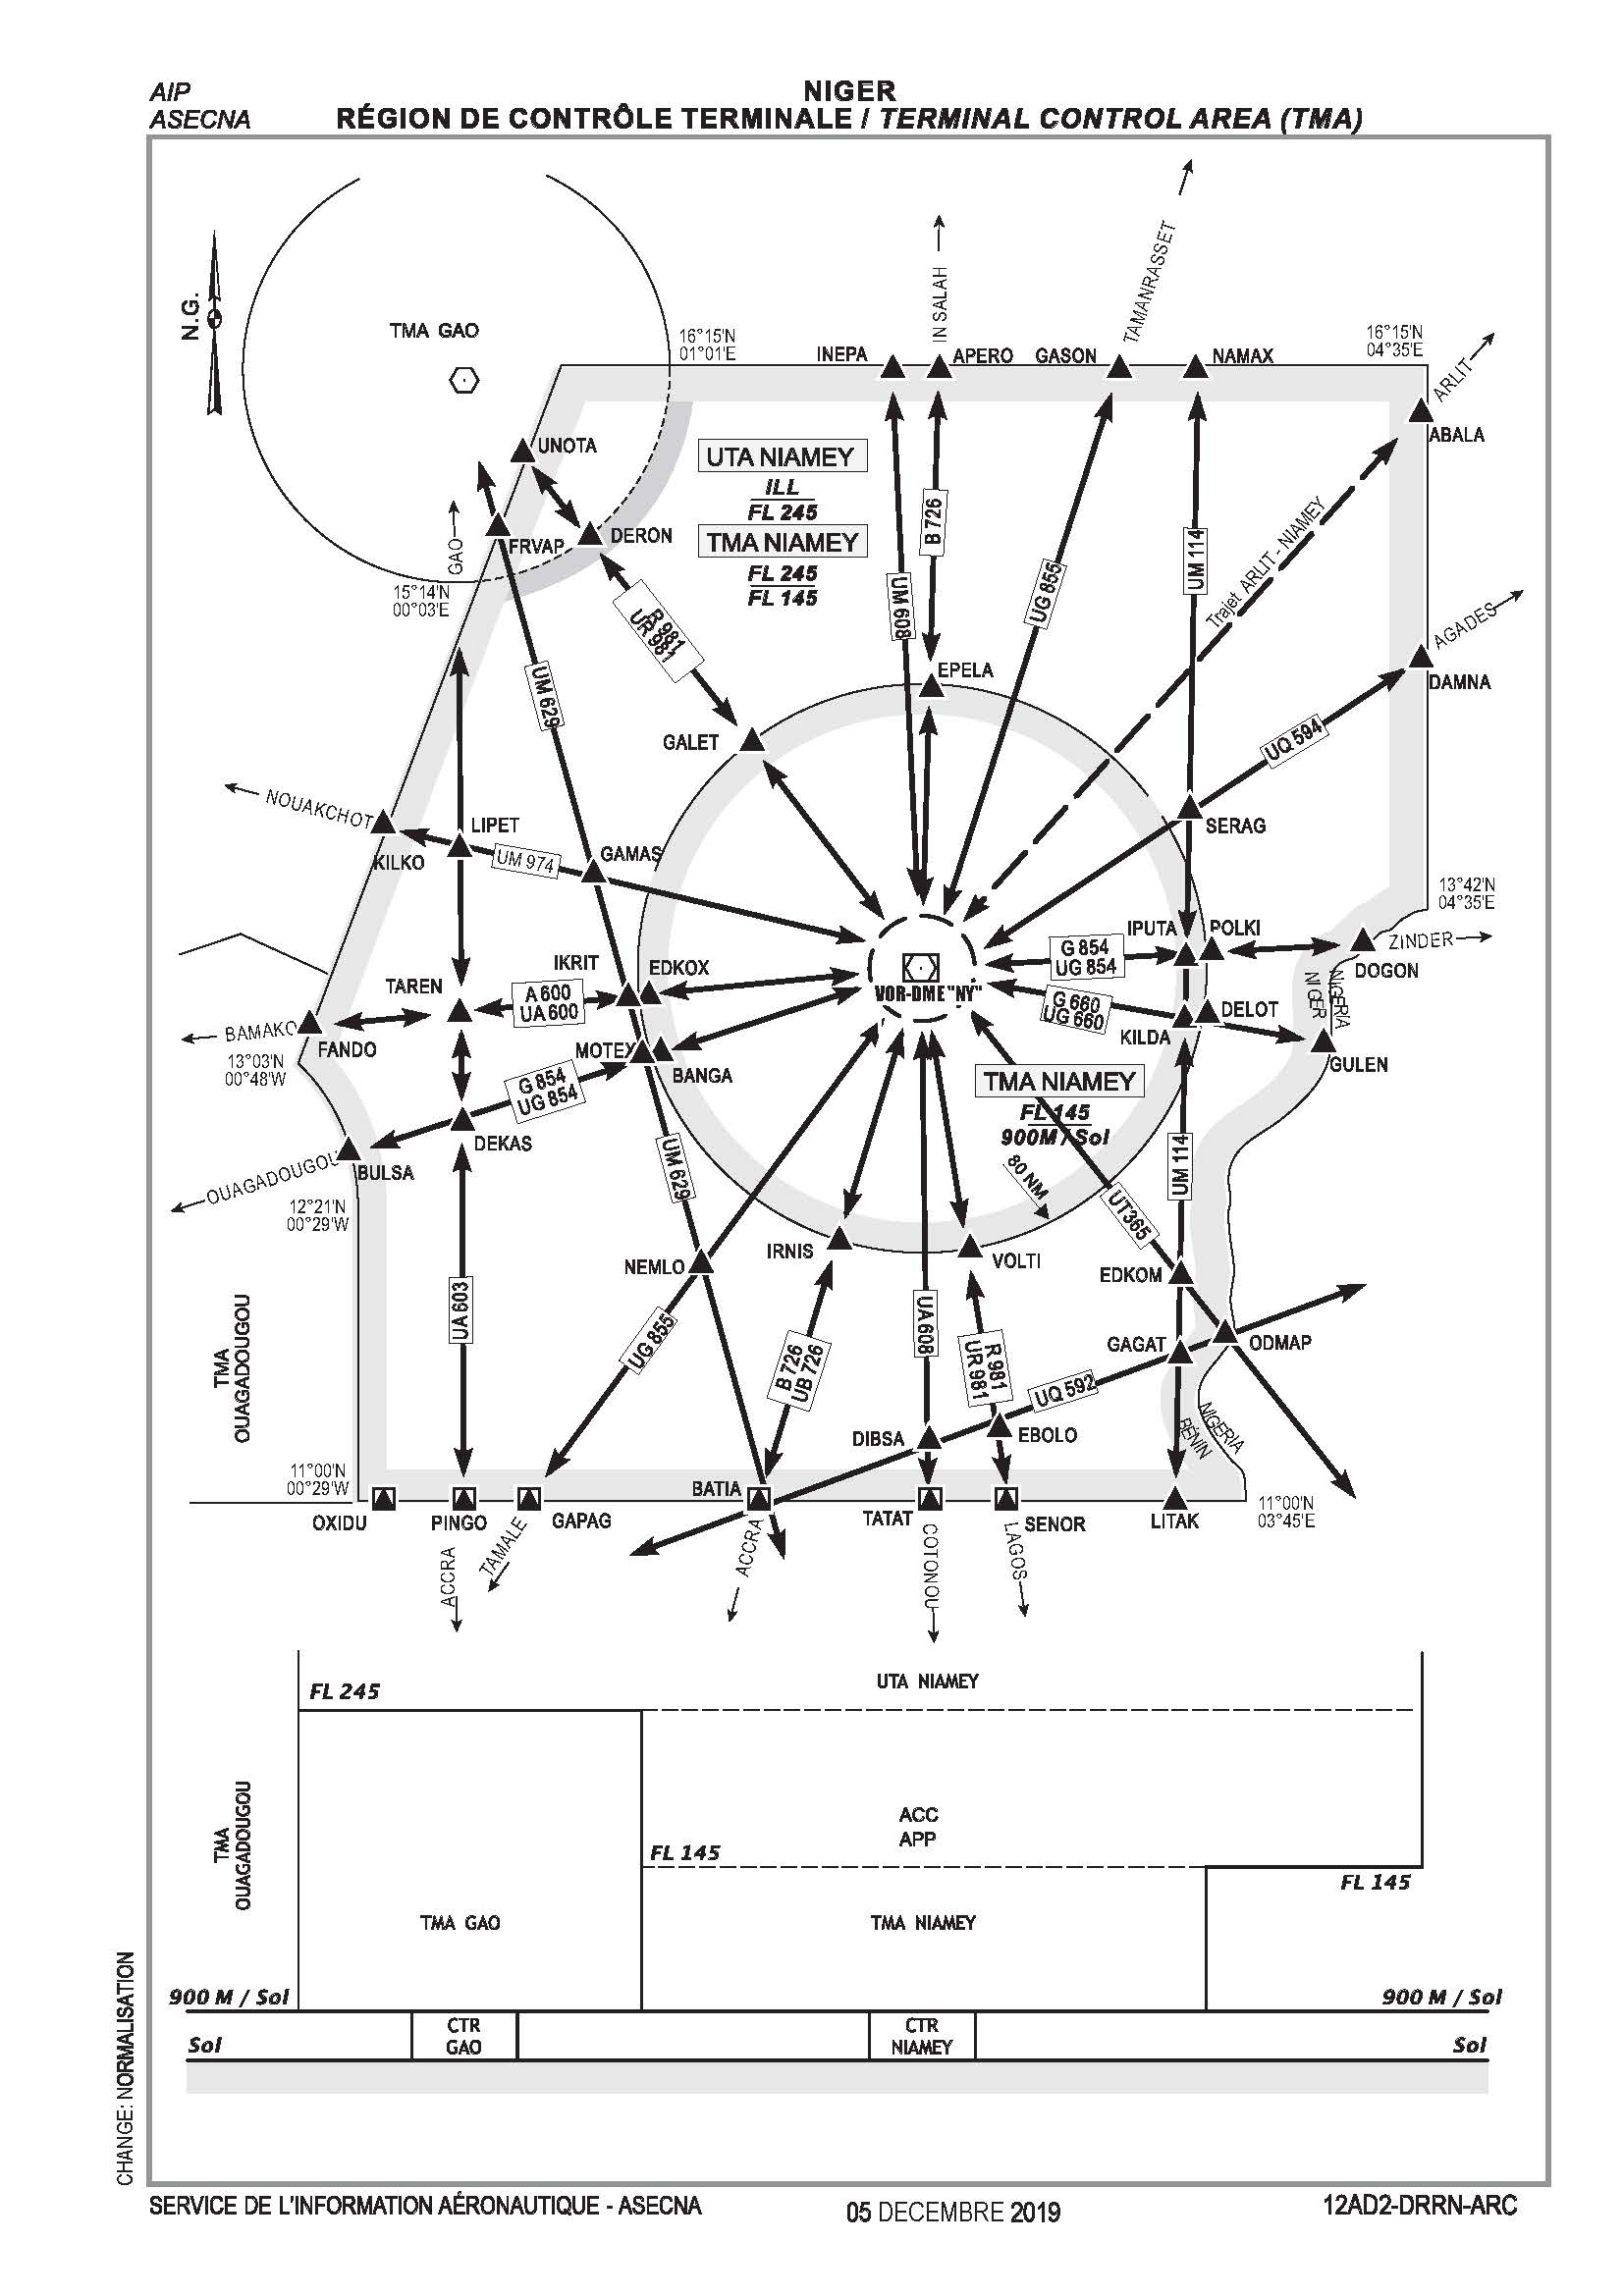

## **Module 4 — Nettoyage des données et aperçu**

###4.1 Nettoyage des donnees ADSB de flightradar24 et transformation en objet `traffic`





**Nettoyage des identifiants ADS-B**

La fonction `nettoyer_identifiants` applique deux opérations successives sur
un DataFrame ADS-B pour garantir que chaque point de trajectoire est
exploitable analytiquement.

**Étape 1 — Suppression des doublons exacts**

Une ligne est considérée comme un doublon si elle est identique à une autre
sur **toutes** ses colonnes. Une seule occurrence est conservée,
les autres sont supprimées.

**Étape 2 — Traitement des lignes sans identifiant vol**

Chaque point de trajectoire doit être rattaché à un vol identifié par son
**callsign** (indicatif radio) et son **numéro de vol** (`flight`). Une ligne
sans ces deux informations ne peut pas être associée à un vol précis et devient
inutilisable pour les analyses de séparation, de conformité ou de performance.

La stratégie appliquée est la suivante :

1. Les lignes ayant au moins un des deux identifiants sont conservées telles
   quelles.
2. Pour les lignes sans `callsign` **et** sans `flight`, on cherche si leur
   `fr24_id` apparaît ailleurs dans le dataset avec un identifiant connu.
   Si c'est le cas, la ligne récupère le callsign ou le flight de son jumeau.
3. Si aucun jumeau identifié n'existe pour ce `fr24_id`, la ligne est
   supprimée — elle ne peut être rattachée à aucun vol.

**Renommage de colonnes**

En fin de traitement, les colonnes `lat` et `lon` issues du format FR24 sont
renommées en `latitude` et `longitude`, conformément aux conventions attendues
par la bibliothèque `traffic` pour la manipulation des trajectoires.

**Création des objets Traffic**

Une fois les DataFrames nettoyés, chaque dataset est encapsulé dans un objet
`Traffic` de la bibliothèque éponyme.

Un objet `Traffic` regroupe l'ensemble des trajectoires d'un dataset et expose
des méthodes spécialisées pour la manipulation de données de vol : détection
des phases de vol, filtrage par zone géographique, visualisation cartographique, etc.

In [35]:
df_tma_general_net = nettoyer_identifiants(df_tma_general, 'TMA_GENERAL')
df_tma_general2_net = nettoyer_identifiants(df_tma_general2, 'TMA_GENERAL')
df_tma_general3_net = nettoyer_identifiants(df_tma_general3, 'TMA_GENERAL')
df_tma_general4_net = nettoyer_identifiants(df_tma_general4, 'TMA_GENERAL')
df_airprox_net     = nettoyer_identifiants(df_airprox,       'AIRPROX')
df_stca1_net       = nettoyer_identifiants(df_stca1,       'STCA1')
df_stca2_net       = nettoyer_identifiants(df_stca2,       'STCA2')
df_stca3_net       = nettoyer_identifiants(df_stca3,       'STCA3')
df_rmg1_net        = nettoyer_identifiants(df_rmg1,        'RMG_2025')
df_rmg2_net        = nettoyer_identifiants(df_rmg2,        'RMG_2024')
df_depart_net      = nettoyer_identifiants(df_depart,   'DEPARTS')
df_approach_net    = nettoyer_identifiants(df_approach,      'APP')
df_stca_ssr_net    = nettoyer_identifiants(df_stca_ssr,      'STCA_SSR')

Vols     = Traffic(df_tma_general_net)
APX      = Traffic(df_airprox_net)
STCA1    = Traffic(df_stca1_net)
STCA2    = Traffic(df_stca2_net)
STCA3    = Traffic(df_stca3_net)
RMG_2025 = Traffic(df_rmg1_net)
RMG_2024 = Traffic(df_rmg2_net)


,Étape,Opération,Lignes avant,Lignes supprimées,Lignes restantes
0,1,Lignes entièrement identiques supprimées,"2,586",0,"2,586"


,Catégorie,Lignes,Action
0,Sans callsign & flight,125,détectées
1,fr24_id récupérable,4,callsign/flight récupéré
2,fr24_id orphelin,121,supprimées


,Indicateur,Valeur
0,Lignes initiales,"2,586"
1,Doublons exacts,0
2,Orphelins supprimés,121
3,Lignes finales,"2,465"


,Étape,Opération,Lignes avant,Lignes supprimées,Lignes restantes
0,1,Lignes entièrement identiques supprimées,"6,140",0,"6,140"


,Catégorie,Lignes,Action
0,Sans callsign & flight,139,détectées
1,fr24_id récupérable,0,callsign/flight récupéré
2,fr24_id orphelin,139,supprimées


...

,Catégorie,Lignes,Action
0,Sans callsign & flight,0,détectées
1,fr24_id récupérable,0,callsign/flight récupéré
2,fr24_id orphelin,0,supprimées


,Indicateur,Valeur
0,Lignes initiales,360
1,Doublons exacts,0
2,Orphelins supprimés,0
3,Lignes finales,360


,Étape,Opération,Lignes avant,Lignes supprimées,Lignes restantes
0,1,Lignes entièrement identiques supprimées,"1,046",0,"1,046"


,Catégorie,Lignes,Action
0,Sans callsign & flight,0,détectées
1,fr24_id récupérable,0,callsign/flight récupéré
2,fr24_id orphelin,0,supprimées


,Indicateur,Valeur
0,Lignes initiales,"1,046"
1,Doublons exacts,0
2,Orphelins supprimés,0
3,Lignes finales,"1,046"


### 4.3 Aperçu des STCA (avril 2026)

In [36]:
print("APERÇU DU DATAFRAME STCA")
print("=" * 70)
print(f"Dimensions      : {df_STCA.shape[0]} lignes x {df_STCA.shape[1]} colonnes")
df_STCA.head(3)

APERÇU DU DATAFRAME STCA
Dimensions      : 83 lignes x 18 colonnes


,Aircraft,Compared Aircraft,Conflict From,Conflict To,Duration,Computed Minimum Distance,Aircraft Altitude,Compared Aircraft Altitude,Aircraft Speed,Compared Aircraft Speed,Aircraft SSR-Code,Compared Aircraft SSR-COde,Aircraft Climb Rate,Compared Aircraft Climb Rate,Aircraft Pos X,Aircraft Pos Y,Compared Aircraft Pos X,Compared Aircraft Pos Y
0,NaN,KQA116,2026-04-02 10:04:03,2026-04-02 10:04:03,00:00:00,0.04,40000.00,39975.00,450.07,461.63,0,0,16.35,0.00,501.00,228.54,500.92,228.58
1,NaN,ETH932,2026-04-02 13:34:14,2026-04-02 13:34:42,00:00:28,0.01,37000.00,37000.00,516.54,516.03,5361,5361,0.00,0.00,457.75,-215.12,458.50,-215.18
2,NaN,DTA650,2026-04-03 03:18:13,2026-04-03 03:18:36,00:00:23,17.23,37000.00,36000.00,484.02,448.60,0,0,0.00,0.00,-464.67,174.11,-456.31,159.04


### 4.3 Aperçu des plans de vol FPL (01 au 10 avril 2026)

In [37]:
df_FPL.columns = df_FPL.columns.str.lstrip()
FPL = df_FPL[df_FPL['Texte'].fillna("").str.strip().ne("")].iloc[:, :-1]
FPL = FPL.drop_duplicates(subset=['Texte'], keep="first")
print(f"Dimensions FPL  : {FPL.shape[0]} lignes x {FPL.shape[1]} colonnes")
FPL.head()

Dimensions FPL  : 992 lignes x 18 colonnes


,Direction,Temps de Création,Prio,FamilyId,Destinataires,First Recipient Address,FilTim,Origine,Circuit,EMID,IMID,Incomplete Pathname,IPM Identificateur,Type,First Reported Recipient,Code du Motif,Code de Diagnostic,Texte
0,Input,2026-04-01 00:00:11.893,FF,ANA2914,[DRZZZQZX],DRZZZQZX,311159,EDDFETHX,,ANA2914,349.1775001611.0,,,FPL,,,,(FPL-ETH3848-IS-B77L/H-SDE1E3FGHIJ1J2J3J4J5J7...
28,Input,2026-04-01 00:02:47.423,FF,341.1775001767.25,[GQNNFDPA],GQNNFDPA,11202,DRRRFDPB,,LST3291,341.1775001767.25,,,FPL,,,,(FPL-AFR863/A5335-IS-A332/H-SDE2E3FGHIJ3J5M1P...
36,Input,2026-04-01 00:02:56.975,FF,341.1775001776.30,[GQNNFDPA],GQNNFDPA,11202,DRRRFDPB,,LST3296,341.1775001776.30,,,FPL,,,,(FPL-AFR989/A5316-IS-B772/H-SWYDE2E3FGHIJ3J5M...
44,Input,2026-04-01 00:03:04.631,FF,ANA0013,[DNKKZQZX DNMMZTZX],DNKKZQZX,11202,EKBICPUF,,ANA0013,349.1775001784.32,,,FPL,,,,(FPL-PVV8642-IN-B742/H-SDFGHIRWY/LB1-HKMO0400...
59,Input,2026-04-01 00:05:35.832,FF,ANA0023,[DBBBFPLX DGACFPLX DNKKZQZX],DBBBFPLX,11204,EDDFUAEK,,ANA0023,349.1775001935.53,,,FPL,,,,(FPL-UAE6M-IS-B77W/H-SDE2E3FGHIJ3J5M1P2RWXYZ/...


### 4.4 Aperçu des MSAW (avril 2026)

In [38]:
MSAW = df_MSAW.drop_duplicates().reset_index(drop=True).copy()
MSAW.columns = MSAW.columns.str.lstrip()
print("=" * 70)
print(f"Dimensions MSAW : {MSAW.shape[0]} lignes x {MSAW.shape[1]} colonnes")
MSAW.head()

Dimensions MSAW : 188 lignes x 4 colonnes


,Aircraft Callsign,Start Time of Warning,End Time of Warning,Duration
0,MSS301,2026-04-01 09:51:00,2026-04-01 09:53:00,00:02:00
1,ETH936,2026-04-01 10:37:00,2026-04-01 10:39:00,00:02:10
2,6N306,2026-04-01 11:38:00,2026-04-01 11:38:00,00:00:40
3,6N306,2026-04-01 11:39:00,2026-04-01 11:42:00,00:03:00
4,SKK046,2026-04-01 15:31:00,2026-04-01 15:31:00,00:00:40


### 4.5 Aperçu des Billings (avril 2026)

In [39]:
BILLING = df_billing.drop_duplicates().reset_index(drop=True).copy()
BILLING.columns = BILLING.columns.str.lstrip()
BILLING['Date'] = pd.to_datetime(BILLING['Date'])
print(f"Dimensions Billing : {BILLING.shape[0]} lignes x {BILLING.shape[1]} colonnes")
BILLING.head()

Dimensions Billing : 5443 lignes x 15 colonnes


,Callsign,REG,Type,Origine,Destination,Règle de vol,Statut,Operation_Type,Billing_Type,Date,Number_Count,Position1,Time1,Position2,Time2
0,TAP281,CSTUG,A339,LPPT,FQMA,I,S,OVF,INTERNATIONAL,2026-04-01,192,IKTAV,2156,RAKOM,2214
1,BAW74X,GZBLJ,B78X,DNMM,EGLL,I,S,OVF,INTERNATIONAL,2026-04-01,735,UBEVA,2309,EREBO,2352
2,BAW55G,GXLEA,A388,EGLL,FAOR,I,S,OVF,INTERNATIONAL,2026-04-01,546,TOBUK,2207,INISA,2243
3,BAW58L,GXWBG,A35K,FACT,EGLL,I,S,OVF,INTERNATIONAL,2026-04-01,866,MOLIT,2311,ERKEL,0002
4,CFG290,DANRP,A339,EDDF,FACT,I,S,OVF,INTERNATIONAL,2026-04-01,192,IKTAV,2209,RAKOM,2227


## **Module 6 — Préparation des données pour analyse**

**Bounding box** : élimine les points lointains par comparaison de bornes

**Test point-dans-polygone** : précision sur le contour exact via Shapely (appliqué uniquement aux points ayant passé le filtre rapide)

In [40]:
df_clean = nettoyer_positions_altitudes(df_tma_general2_net, alt_min=0, alt_max=65000)
df_uta, poly_uta_shapely = filtrer_d(df_clean, contour_uta)
print("Nettoyage et filtrage géographie terminés. Le dataframe est df_uta\n")

Positions invalides : 0
Altitudes aberrantes : 0
Points conserves : 6,001 (100.0 %)
Filtre bbox    : 31 points écartés
Filtre polygone : 912 points écartés
Points dans UTA : 5058
Nettoyage et filtrage géographie terminés. Le dataframe est df_uta



### 6.1 Taux d'emport de transpondeur SSR et ADS-B

La case 10b du plan de vol OACI décrit les équipements de surveillance embarqués. Le tableau ci-dessous rappelle les codes utilisés.

|Equipement | Code | Description |
|----------|------|-------------|
| SSR modes A et C | A | Transpondeur mode A (4 chiffres, 4096 codes) |
| SSR modes A et C | C | Transpondeur mode A (4 chiffres, 4096 codes) et mode C |
| SSR Mode S | S | Transpondeur mode S avec transmission altitude pression et identification aéronef |
| SSR Mode S | P | Mode S avec altitude pression sans identification aéronef |
| SSR Mode S | I | Mode S avec identification aéronef sans altitude pression |
| SSR Mode S | X | Mode S sans identification ni altitude pression |
| SSR Mode S | E | Mode S avec identification, altitude pression et squitters longs ADS-B |
| SSR Mode S | H | Mode S avec identification, altitude pression et surveillance enrichie |
| SSR Mode S | L | Mode S avec identification, altitude pression, ADS-B et surveillance enrichie |
| ADS-B | B1 | ADS-B émission 1090 MHz spécialisée |
| ADS-B | B2 | ADS-B émission et réception 1090 MHz spécialisée |
| ADS-B | U1 | ADS-B émission utilisant UAT |
| ADS-B | U2 | ADS-B émission et réception utilisant UAT |
| ADS-B | V1 | ADS-B émission utilisant VDL mode 4 |
| ADS-B | V2 | ADS-B émission et réception utilisant VDL mode 4 |

> UAT (**Universal Access Transponder**, 978 MHz) : standard ADS-B d'origine américaine, principalement utilisé par l'aviation générale.

Répartition des équipements de surveillance déclarés à la case 10b du plan de vol des vols ayant traversé l'espace aérien du Niger du 1er au 10 avril 2026

In [41]:
STATUT_EQ = (analyse_ssr_adsb(FPL)* 100).round(1)
line = STATUT_EQ.hvplot.bar( y="TAUX", height=500,rot=70,
    color="TAUX", cmap="Set3", legend="top_left",
    title="Taux d'emport par équipement de surveillance")
line

:Bars   [index]   (TAUX)

In [42]:
STATUT_EQ.columns = ["TAUX_%"]
STATUT_EQ

,TAUX_%
SSR_S_CODE_L,80.90
SSR_MODE_C,70.00
ADSB_CODE_B1,67.20
SSR_S_CODE_H,23.20
SSR_S_CODE_S,12.40
ADSB_CODE_B2,4.60
SSR_S_CODE_E,2.00
ADSB_CODE_V1,0.60
ADSB_CODE_U1,0.40
SSR_S_CODE_I,0.30


Synthèse sur l'emport d'équipement de surveillance

In [43]:
EQ = (taux_equipement(FPL) * 100).round(1)
line = EQ.hvplot.bar( y="TAUX", height=500,rot=70,
    color="TAUX", cmap="Set3", legend="top_left",
    title="Taux d'emport de transpondeurs SSR et ADS-B")
line

:Bars   [index]   (TAUX)

In [44]:
EQ.columns = ["TAUX_%"]
EQ

,TAUX_%
SSR_SEUL,23.80
ADSB_SEUL,0.00
SSR_ET_ADSB,72.10
AUCUN_DES_DEUX,4.10
SSR_TOTAL,95.90
ADSB_TOTAL,72.10


###6.2 Exploration des données

Il est indispensable de caractériser le jeu de données afin de vérifier sa représentativité et d'en apprécier le potentiel d'exploitation. Cette phase d'exploration permet de décrire les principales caractéristiques du dataset, notamment sa taille, sa période de couverture, la nature des vols observés, les équipements de surveillance déclarés, ainsi que la répartition temporelle du trafic.

Le jeu de données utilisé dans le cadre de cette étude est constitué de 4 sous-datasets indépendants, chacun couvrant une période continue de 24h sur la TMA/UTA de Niamey.



In [45]:
DATASET = pd.concat([df_tma_general_net, df_tma_general2_net, df_tma_general3_net, df_tma_general4_net])
SYNTHESE_FR24 = synthese_fr24(DATASET, aerodromes_locaux=["DRRN"])
SYNTHESE_FR24

,Indicateur,Valeur
0,Nombre de lignes,21150
1,Nombre de vol,391
2,Jours couverts,28/10/2025 au 29/10/2025 | 07/04/2026 au 10/04...
3,ARRIVEES,36
4,DEPARTS,38
5,SURVOLS,317


Les sources des données de surveillance

In [46]:
TABLEAU_SOURCES = tableau_sources(DATASET)
TABLEAU_SOURCES

,Nb_vols,Part (%)
source,,
ADSB,183,96.30
ESTIMATED,25,13.20
MLAT,5,2.60


In [47]:
df = DATASET.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

vols_par_heure = (df.groupby(df["timestamp"].dt.hour)["icao24"]
      .nunique().rename("Nb_vols").sort_index())
df_plot = vols_par_heure.reset_index()
df_plot['timestamp'] = df_plot['timestamp'].astype(str)

diagramme_heures = df_plot.hvplot.bar(
    x='timestamp',
    y='Nb_vols',
    height=450,
    rot=0,
    xlabel="Heure UTC",
    ylabel="Nombre de vols",
    title="Nombre de vols par heure de la journée",
    color="Nb_vols",
    cmap="Blues"
)
diagramme_heures

:Bars   [timestamp]   (Nb_vols)

Nous allons choisir le dataset du 07 au 08 avril 2026 pour une étude comparative.





In [48]:
def comparer_fr24_reel(df_fr24, df_billing, aerodrome="DRRN"):
    # FR24 : classer par origine/destination, un vol = un fr24_id
    def cat(orig, dest):
        if dest == aerodrome: return "ARRIVEES"
        if orig == aerodrome: return "DEPARTS"
        return "SURVOLS"
    f = df_fr24.drop_duplicates("icao24")
    n_fr24 = f.apply(lambda r: cat(r["orig_icao"], r["dest_icao"]), axis=1).value_counts()

    # Reel : Operation_Type du Billing (OVF -> SURVOLS)
    map_ope = {"ARR": "ARRIVEES", "DEP": "DEPARTS", "OVF": "SURVOLS"}
    n_reel = df_billing["Operation_Type"].map(map_ope).value_counts()

    j_fr24 = f"{df_fr24['timestamp'].min():%d/%m/%Y} au {df_fr24['timestamp'].max():%d/%m/%Y}"
    j_reel = f"{df_billing['Date'].min():%d/%m/%Y} au {df_billing['Date'].max():%d/%m/%Y}"

    lignes = [{"Indicateur": "Jours couverts", "Valeur_FR24": j_fr24, "Valeur_Reel": j_reel}]
    for c in ["ARRIVEES", "DEPARTS", "SURVOLS"]:
        lignes.append({"Indicateur": c,
                       "Valeur_FR24": int(n_fr24.get(c, 0)),
                       "Valeur_Reel": int(n_reel.get(c, 0))})
    tab = pd.DataFrame(lignes)
    tab["% FR24/Reel"] = tab.apply(
        lambda r: round(100 * r["Valeur_FR24"] / r["Valeur_Reel"], 1)
                  if isinstance(r["Valeur_FR24"], int) and r["Valeur_Reel"] else "", axis=1)
    return tab

In [49]:
vols_uta = vols_uta_billing(BILLING, navaids, poly_uta_shapely, "2026-04-08")

afficher_html("Synthèse des mouvements - UTA Niamey (08/04/2026)", style='sous_titre')
display(vols_uta["Operation_Type"].value_counts().to_frame("Nombre de vols"))
print(f"Total des vols : {len(vols_uta)}")
#display(vols_uta[["Callsign", "Type", "Operation_Type", "Position1", "Position2"]].sort_values("Operation_Type"))

,Nombre de vols
Operation_Type,
OVF,23
ARR,15
DEP,13


Total des vols : 51


In [50]:
comparaison = comparer_fr24_reel(df_tma_general3_net, vols_uta)   # vols_uta = sortie du Billing
display(comparaison)

,Indicateur,Valeur_FR24,Valeur_Reel,% FR24/Reel
0,Jours couverts,07/04/2026 au 08/04/2026,08/04/2026 au 08/04/2026,
1,ARRIVEES,8,15,53.30
2,DEPARTS,11,13,84.60
3,SURVOLS,78,23,339.10


## **Module 7 — Filtrage géographique UTA , TMA Niamey**

Pour les trajectoires, nous avons:


*   **Bleu** pour les survols
*   **Jaune** pour les arrivées
*   **Orange** pour les départs



In [51]:
carte_espaces = afficher_toutes_zones()
ajouter_trajectoires_sur_carte(carte_espaces, df_uta)

Map(center=[14.5, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

## **Module 8 — Id1. Minimum des taux de rapprochement des aéronefs**


Nous cherchons dans cette partie à mesurer le minimum sur une periode donnée des taux de rapprochements entre des aeronefs dans l'uta Niamey.

Le **Manuel d'exploitation ASECNA applicable au CCR de Niamey**, fixe les normes de séparation en guidage radar à appliquer dans l'UTA et la TMA2.

*   Séparation verticale : 1 000 ft dans l'espace RVSM et en dessous, 2000 ft au-dessus
*   Séparation horizontale : 10 NM entre symboles de position (5 NM pour un aéronef en montée ou descente derrière à un aéronef stable)

Deux aéronefs sont en perte de séparation si **simultanément** ces minima ne sont plus respectés.

Le taux de rapprochement $Tr(i,j)$ entre deux aéronefs i et j à un instant donné est défini comme le maximum entre le taux de rapprochement horizontal $Tr_h(i,j)$ et le taux de rapprochement vertical $Tr_v(i,j)$ à cet instant. On a :


$
Tr_h(i,j)=\frac{d_{ij}}{10 NM}
$ , $d_{ij}$ étant la separation horizontal

$
Tr_v(i,j)=\frac{|\Delta h_{ij}|}{1000 ft}
$, $Δh_{ij}$ la séparation verticale entre les deux avion.

$$
Tr(i,j)=\max\left(Tr_h(i,j),Tr_v(i,j)\right)
$$

A la fin de la période nous déterminons le plus petit des $Tr$ qui constitue l'indicateur $Id1$.
$$
Id1=\min\left(Tr(i,j)\right)
$$

Il y a Airprox si $Id1 < 1$


Nous avons utilisé la méthode `closest_point_of_approach(lateral_sep=100NM, vertical_sep=20000ft)` pour éviter d'avoir un objet `cpa.data` vide en absence d'airprox et calculer les taux de rapprochement $Tr(i,j)$.

Les colonnes `latéral` et `vertical` fournies par cette méthode ont été utilisées pour calculer respectivement $Tr_h(i,j)$ et $Tr_v(i,j)$

In [52]:
paires = tab_Tr(df_tma_general4_net)

  0%|          | 0/2 [00:00<?, ?it/s]

In [53]:
Id1 = paires['Tr'].min()
paires = ajouter_tolerance(paires, "Id1")
conclusion_id1(Id1,tab_paires = paires)

,timestamp,icao24_i,aeronef_i,icao24_j,aeronef_j,lateral,vertical,Trh,Trv,Tr,Tol_Tr
0,2026-04-09 15:36:58+00:00,3f22e61f,APK7579,3f23e5d6,DWC055,3.35,1000,0.34,1.00,1.00,0.02500
1,2026-04-09 15:06:57+00:00,3f22c7b8,BEL5TA,3f22cb25,AFR988,8.81,1000,0.88,1.00,1.00,0.02500
2,2026-04-09 14:59:28+00:00,3f22c7b8,BEL5TA,3f2312a4,WFL9719,13.99,1000,1.40,1.00,1.40,0.02500
3,2026-04-09 12:30:29+00:00,3f2265bd,THY15,3f230783,ETH908,14.46,1000,1.45,1.00,1.45,0.02500
4,2026-04-09 14:54:28+00:00,3f22c423,BEL27A,3f2312a4,WFL9719,14.99,1000,1.50,1.00,1.50,0.02500


## **Module 9 — Id2 Taux de conformité au franchissement des obstacles**

Le franchissement d'obstacles constitue un critère de sécurité fondamental dans les procédures aux instruments publiées par l'ASECNA pour l'aérodrome de Niamey (DRRN). Les procédures de départ aux instruments (SID) et d'approche aux instruments (STAR) intègrent des marges de franchissement calculées à partir des positions et hauteurs des obstacles recensés dans l'AIP Niger (section AD 2.10).

$Id_2$ évalue le respect des marges de franchissement d'obstacles lors des phases d'approche finale et de départ.

Pour chaque piste, l'obstacle déterminant est identifié comme celui imposant la contrainte de franchissement la plus pénalisante. Les résultats obtenus pour les deux sens de piste sont ensuite regroupés au sein d'un indicateur unique caractérisant le niveau global de sécurité vis-à-vis des obstacles.

Le calcul est réalisé sur l'ensemble des trajectoires de départ et d'arrivée observées au cours d'une journée. Pour chaque trajectoire, deux taux normalisés sont déterminés :

$$T_{xv}=\frac{d_v}{MFO}$$

$$T_{xh}=\frac{d_h}{D_{\mathrm{protection}}}$$

où :

$d_v$ est la distance verticale entre l'aéronef et l'obstacle déterminant ;
$d_h$ est la distance horizontale entre l'aéronef et cet obstacle ;
$MFO$ est la marge minimale de franchissement d'obstacles définie par les critères PANS-OPS ;
$D_{\mathrm{protection}}$ est la largeur de l'aire de protection applicable à la procédure.

$$Id2 = \min_{\text{jour}}\left(\min_{\text{traj}}\left(\max(T_{xv}, T_{xh})\right)\right)$$


Si $Id_2 \ge 1$ alors l'intégralité des vols de la journée a respecté les marges de sécurité. Sinon, une violation de marge a été détectée.

**Représentation sur carte interactive des obstacles d'aérodrome de Niamey**
> Cliquer sur un obstacle pour afficher ses informations



In [54]:
m = Map(center=(13.481547, 2.183614), zoom=14) # ARP DRRN
for _, obs in OBSTACLES.iterrows():
    marker = Marker(location=(obs.lat, obs.lon))
    marker.popup = HTML(
        value=f"<b>{obs.nom}</b><br>"
              f"{obs.type}<br>"
              f"{obs.altitude_ft} ft<br>"
              f"{obs.balisage}"
    )
    m.add(marker)
m

Map(center=[13.481547, 2.183614], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', …

Les obstacles critiques pour les opérations de decollage et attérrissage sont : NDB NY (Altitude : 715 ft) pour la piste 09R et VOR/DME (Alt:722 ft) et ILS LOC

La Marge de Franchissement d'Obstacle à l'arrivée vaut :
$$\text{MFO}_{\text{Arrivée}} = 75\text{ mètres}$$En montée initiale : La MFO est dynamique et dépend de la distance de l'obstacle par rapport à la DER

$$\text{MFO}_{\text{Départ}} = 0.008 \times \text{Distance}_{\text{Obstacle / DER}}$$


$D_{protection}$ par les procedure PANS OPS

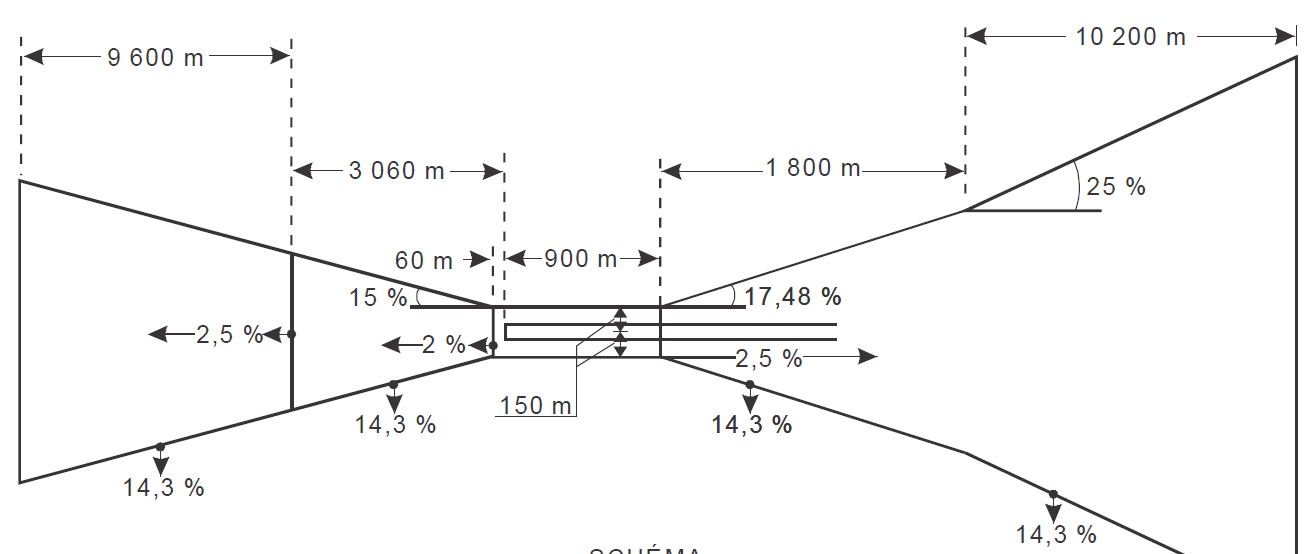

D'après le PANS OPS, à 60 du seuil de la piste, $D_{protection}$ = 300m (largeur de la bande de piste) et s'évase de 15% jusqu'à 12660 m.

* NDB NY est situé à D = 3084m du seuil 09R
* VOR/DME est situé à D = 390m du seuil 27L.

La distance de protection d'un obstacle situé à une distance D du seuil est : $$D_{protection} = 300 + 2×(D-60) × tan (15°)$$

In [55]:
df_obstacles["D_protection_m"] = df_obstacles["D_seuil_m"].apply(d_protection_pans_ops)
df_obstacles

,Seuil,nom,lat,lon,alt_ft,dist_der_m,MFO_DEP_ft,MFO_ARR_ft,D_seuil_m,D_protection_m
0,09R,NDB NY,13.48,2.16,715,2784,73.07,246.06,3084,1920.56
1,27L,VOR/DME,13.48,2.20,722,190,4.99,246.06,390,476.85



Avant le calcul de l'indicateur Id2, les trajectoires ADS-B font l'objet d'un prétraitement afin de ne conserver que les informations nécessaires à l'analyse du franchissement des obstacles.

La fonction `detecter_dep_arr()` identifie tout d'abord les mouvements de départ et d'arrivée .

La fonction `detecter_piste()` détermine ensuite automatiquement la piste utilisée (09R ou 27L) à partir de la trajectoire de chaque aéronef. Cette information permet d'associer à chaque mouvement l'obstacle critique correspondant au départ ou à l'arrivée.

Enfin, la fonction `ajouter_qnh()` corrige les altitudes issues de FlightRadar24. En effet, les altitudes ADS-B sont exprimées en altitude pression avec le calage standard **1013,25 hPa**, alors que les altitudes des obstacles publiées dans l'AIP sont référencées au niveau moyen de la mer (MSL).

Les observations horaires de pression réduite au niveau moyen de la mer (`pres`) sont récupérées automatiquement pour la station météorologique **Niamey-Aero (61052)** grâce à la bibliothèque **Meteostat**, puis associées à chaque point de trajectoire selon l'horodatage le plus proche.

L'altitude corrigée est calculée selon :

$$H_{QNH}=H_{FR24}+\left(QNH-1013.25\right)\times28$$

avec :

- $H_{FR24}$ : altitude issue des données FlightRadar24 ;
- $QNH$ : pression atmosphérique locale en hPa ;
- $1013.25$ hPa : pression standard ISA ;
- $28$ ft/hPa : coefficient moyen de conversion entre une variation de pression et une variation d'altitude.

À l'issue de ce prétraitement, chaque point de trajectoire est caractérisé par sa phase de vol (départ ou arrivée), la piste utilisée et son altitude corrigée au QNH.

In [56]:
df_dep_arr = detecter_dep_arr(df_tma_general_net)
df_rwy = detecter_piste(df_dep_arr)
df_rwy = ajouter_qnh(df_rwy)

In [57]:
df_rwy.head(3)

,icao24,latitude,longitude,track,altitude,gspeed,vspeed,squawk,timestamp,source,flight,callsign,hex,type,reg,painted_as,operating_as,orig_iata,orig_icao,dest_iata,dest_icao,eta,query_timestamp_utc,_source,phase,piste,QNH,QNH_estime,altitude_qnh
0,3cdb62e8,13.48,2.20,267,0,0,0,0,2025-10-28 07:17:53+00:00,ADSB,KP47,SKK047,040185,B738,ET-AXI,SKK,ETH,NIM,DRRN,OUA,DFFD,NaN,2025-10-28 07:18:00+00:00,TMA_GENERALE_2025-10-28_tranche1sur8.csv,DEP,27L,1012.00,False,-35.00
1,3cdb62e8,13.48,2.17,266,1275,173,2240,0,2025-10-28 07:18:58+00:00,ADSB,KP47,SKK047,040185,B738,ET-AXI,SKK,ETH,NIM,DRRN,OUA,DFFD,NaN,2025-10-28 07:19:00+00:00,TMA_GENERALE_2025-10-28_tranche1sur8.csv,DEP,27L,1012.00,False,1240.00
2,3cdb62e8,13.47,2.12,245,2800,226,1216,0,2025-10-28 07:19:58+00:00,ADSB,KP47,SKK047,040185,B738,ET-AXI,SKK,ETH,NIM,DRRN,OUA,DFFD,NaN,2025-10-28 07:20:00+00:00,TMA_GENERALE_2025-10-28_tranche1sur8.csv,DEP,27L,1012.00,False,2765.00


In [58]:
df_rwy_filtre = df_rwy.dropna(subset=['piste'])

df_id2 = calcul_id2(df_rwy_filtre, df_obstacles)

In [59]:
Id2 = df_id2.Tx.min()

if Id2 < 1:
    afficher_html(f"Id2 = {Id2:.3f} < 1", style='erreur')
    afficher_html("Attention : les marges de franchissement d'obstacles n'ont pas été respectées pour les vols suivants :", style='sous_titre')
    display(df_id2[df_id2.Tx < 1].sort_values('Tx'))
else:
    afficher_html(f"Id2 = {Id2:.3f} ≥ 1", style='succes')
    afficher_html("Les marges de franchissement d'obstacles ont été respectées sur l'ensemble de la période.", style='sous_titre')
    display(df_id2.sort_values('Tx').head(5))

,date_vol,heure_vol,icao24,callsign,phase,piste,obstacle,dh_m,dv_ft,Txh,Txv,Tx
6,2025-10-28,19:42:59,3cdd46ed,VRE746,ARR,09R,NDB NY,540.29,172.00,0.28,0.70,0.70


## **Module 10 — Id3. Taux de pertinence d’alertes STCA**

L'alerte STCA (Short-Term Conflict Alert) a pour but de prévenir les contrôleurs d'une perte de séparation imminente entre les avions.

Le système surveille en continu les trajectoires radar ou ADS-B, prédit la position des aéronefs sur un horizon court, le look-ahead, de l'ordre de deux minutes,  l'alerte quand deux aéronefs risquent de franchir en même temps les minima de séparation horizontal et vertical dans cet horizon.

Pour chaque alerte STCA du mois d'avril 2026, les trajectoires des deux aéronefs sont extrapolées de 10s en 10s sur 2 minutes à partir de paramètres cinématiques (vitesse sol, cap et vitesse verticale supposés constants sur tout l'horizon de prédiction) à $t_0 = Conflict from$, le debut de l'alerte dans la dataframe des alertes `df_STCA`.

La distance horizontale parcourue après un temps $\Delta t$ est calculée par :

$$
D(\Delta t)=gspeed\times\frac{\Delta t}{3600}
$$
La position prédite est obtenue en projetant, avec `great_circle().destination()`, cette distance selon le cap observé.

L'altitude prédite est calculée à partir de la vitesse verticale constante :

$$
H(t)=H_0+V_S\times\frac{\Delta t}{60}
$$

Une alerte est considérée pertinente lorsque la trajectoire prédite conduit simultanément à une perte des séparations horizontale et verticale : $Tr(i,j)^{pred} < 1$


$$
Tr(i,j)^{pred}=\max\left(Tr_h^{pred},Tr_v^{pred}\right)
$$

Avec : $Tr_h(i,j)^{pred}=\frac{d_{ij}^{pred}}{10}$ et  $ Tr_v(i,j)^{pred}=\frac{|\Delta h_{ij}^{pred}|}{1000}$

$$
Id3=\frac{N_{STCA\ pertinents}}{N_{STCA\ totaux}}\times100
$$



###10.1 Les STCA pour lesquelles les deux aéronefs impliqués sont identifiés

Les alertes STCA ayant l'identification des deux aéronefs en conflit sont :

In [60]:
df_STCA_filtre = df_STCA[df_STCA['Aircraft'].notna() & df_STCA['Compared Aircraft'].notna()].copy()
df_STCA_filtre

,Aircraft,Compared Aircraft,Conflict From,Conflict To,Duration,Computed Minimum Distance,Aircraft Altitude,Compared Aircraft Altitude,Aircraft Speed,Compared Aircraft Speed,Aircraft SSR-Code,Compared Aircraft SSR-COde,Aircraft Climb Rate,Compared Aircraft Climb Rate,Aircraft Pos X,Aircraft Pos Y,Compared Aircraft Pos X,Compared Aircraft Pos Y
32,TAR401,THY3KA,2026-04-11 20:49:48,2026-04-11 20:51:38,00:01:50,2.19,36000.00,35000.00,464.69,447.00,6134,3165,0.00,0.00,-173.92,-294.72,-170.65,-290.39
37,UAE783,QTR774,2026-04-13 13:30:09,2026-04-13 13:31:39,00:01:30,7.45,36000.00,37000.00,468.91,520.75,0,0,0.00,0.00,341.21,-202.93,341.59,-202.17
54,RAM545Y,AFR149,2026-04-19 00:36:38,2026-04-19 00:37:12,00:00:34,23.08,37000.00,36000.00,486.63,458.04,6416,5214,0.00,0.00,-340.54,-120.36,-334.03,-133.35


###10.2 Les  STCA pour lesquelles les aéronefs impliqués ne sont pas tous identifiés

Nous considérerons également les alertes STCA pour lesquelles au moins un des aéronefs impliqués ne possède pas d'identification (indicatif d'appel), mais dont les deux codes SSR sont renseignés et distincts.


In [61]:
df_STCA_nan = df_STCA.drop(df_STCA_filtre.index)
# Tirer les lignes où les deux codes SSR sont différents de 0 et ne sont pas égaux
df_STCA_ssr_valid = df_STCA_nan[ (df_STCA_nan['Aircraft SSR-Code'] != 0) &
    (df_STCA_nan['Compared Aircraft SSR-COde'] != 0)&
    (df_STCA_nan['Aircraft SSR-Code'] != df_STCA_nan['Compared Aircraft SSR-COde'])]

In [123]:
df_STCA_ssr_valid

,Aircraft,Compared Aircraft,Conflict From,Conflict To,Duration,Computed Minimum Distance,Aircraft Altitude,Compared Aircraft Altitude,Aircraft Speed,Compared Aircraft Speed,Aircraft SSR-Code,Compared Aircraft SSR-COde,Aircraft Climb Rate,Compared Aircraft Climb Rate,Aircraft Pos X,Aircraft Pos Y,Compared Aircraft Pos X,Compared Aircraft Pos Y,Aircraft_Lat,Aircraft_Lon,Compared_Lat,Compared_Lon
25,EDW86,NaN,2026-04-09 23:28:46,2026-04-09 23:30:50,00:02:04,2.07,37000.00,35975.00,501.46,464.92,3042,7355,0.00,0.00,514.07,-87.21,512.86,-77.04,14.61,12.32,14.78,12.30
31,KLM589,NaN,2026-04-11 19:10:53,2026-04-11 19:13:03,00:02:10,1.55,32000.00,31000.00,511.83,496.30,3166,3127,0.00,0.00,-100.42,-374.21,-94.54,-362.94,9.99,1.80,10.17,1.90
33,DTA653,NaN,2026-04-12 02:29:26,2026-04-12 02:31:25,00:01:59,1.15,35000.00,36000.00,508.89,482.15,1157,3513,0.00,0.00,-263.74,-302.19,-267.64,-293.13,11.15,-0.97,11.30,-1.03
48,VIR478,NaN,2026-04-16 22:42:15,2026-04-16 22:44:15,00:02:00,2.18,39000.00,38000.00,467.99,481.21,2014,7333,0.00,0.00,533.49,-150.19,532.69,-141.19,13.55,12.60,13.70,12.60
55,DTA653,NaN,2026-04-20 02:04:40,2026-04-20 02:06:40,00:02:00,2.65,35000.00,36000.00,490.45,471.64,3341,3512,0.00,0.00,-249.94,-332.23,-252.01,-322.71,10.66,-0.72,10.82,-0.76
60,CFG288,NaN,2026-04-22 23:15:07,2026-04-22 23:15:56,00:00:49,2.27,37000.00,38000.00,478.13,466.91,2575,5612,0.00,0.00,560.80,-234.06,560.06,-224.84,12.14,13.01,12.30,13.00
61,DTA653,NaN,2026-04-23 01:55:06,2026-04-23 01:57:10,00:02:04,0.73,35000.00,36000.00,492.19,492.73,3352,3122,0.00,0.00,-223.66,-388.62,-227.06,-379.96,9.72,-0.27,9.87,-0.33
71,THY4KH,NaN,2026-04-26 21:24:03,2026-04-26 21:26:08,00:02:05,0.79,36000.00,37000.00,444.18,480.36,2333,1247,0.00,0.00,-237.33,-376.47,-231.03,-369.36,9.92,-0.50,10.04,-0.40



> Le Topsky enrégistre les positions des aéronefs des alertes STCA dans un plan obtenu par **projection stéréographique** tangent au géoïde au point `SYSTEM_CENTRE (161500N,0032945E)`(Manuel Topsky).

Afin d'obtenir leur position en coordonnées géographiques WGS84 (latitude, longitude), il est nécessaire d'appliquer la transformation inverse de ladite projection. Cela nous permet de retrouver les coordonnées géographiques des aéronefs avant leur extraction via Flightradar24 API.


In [63]:
scale = 1852.0
longitudes_ac, latitudes_ac = proj_niamey(df_STCA_ssr_valid['Aircraft Pos X'].values * scale,
    df_STCA_ssr_valid['Aircraft Pos Y'].values * scale, inverse=True)

longitudes_comp, latitudes_comp = proj_niamey(df_STCA_ssr_valid['Compared Aircraft Pos X'].values * scale,
    df_STCA_ssr_valid['Compared Aircraft Pos Y'].values * scale,inverse=True)

df_STCA_ssr_valid = df_STCA_ssr_valid.assign(Aircraft_Lat=latitudes_ac, Aircraft_Lon=longitudes_ac,
    Compared_Lat=latitudes_comp, Compared_Lon=longitudes_comp)
#display(df_STCA_ssr_valid.head(2))

In [64]:
# Construction d'une table de correspondance squawk -> callsign
squawk_to_callsign = ( df_stca_ssr_net.dropna(subset=["callsign"]).drop_duplicates(subset=["squawk"])
                      .set_index("squawk")["callsign"])

df_STCA_identifie = df_STCA_ssr_valid.copy()
mask_aircraft = df_STCA_identifie["Aircraft"].isna()
df_STCA_identifie.loc[mask_aircraft, "Aircraft"] = (df_STCA_identifie.loc[mask_aircraft, "Aircraft SSR-Code"]
    .map(squawk_to_callsign))

# Compléter Compared Aircraft lorsqu'il est vide
mask_compared = df_STCA_identifie["Compared Aircraft"].isna()

df_STCA_identifie.loc[mask_compared, "Compared Aircraft"] = (
    df_STCA_identifie.loc[mask_compared, "Compared Aircraft SSR-COde"].map(squawk_to_callsign))
#df_STCA_identifie.head()

###10.3 Les STCA d'avril 2026 : candidats à l'airprox

In [122]:
df_STCA_identifie = df_STCA_identifie[df_STCA_filtre.columns]
df_STCA_cand = pd.concat([df_STCA_filtre, df_STCA_identifie], ignore_index=True)
df_STCA_cand

,Aircraft,Compared Aircraft,Conflict From,Conflict To,Duration,Computed Minimum Distance,Aircraft Altitude,Compared Aircraft Altitude,Aircraft Speed,Compared Aircraft Speed,Aircraft SSR-Code,Compared Aircraft SSR-COde,Aircraft Climb Rate,Compared Aircraft Climb Rate,Aircraft Pos X,Aircraft Pos Y,Compared Aircraft Pos X,Compared Aircraft Pos Y
0,TAR401,THY3KA,2026-04-11 20:49:48,2026-04-11 20:51:38,00:01:50,2.19,36000.00,35000.00,464.69,447.00,6134,3165,0.00,0.00,-173.92,-294.72,-170.65,-290.39
1,UAE783,QTR774,2026-04-13 13:30:09,2026-04-13 13:31:39,00:01:30,7.45,36000.00,37000.00,468.91,520.75,0,0,0.00,0.00,341.21,-202.93,341.59,-202.17
2,RAM545Y,AFR149,2026-04-19 00:36:38,2026-04-19 00:37:12,00:00:34,23.08,37000.00,36000.00,486.63,458.04,6416,5214,0.00,0.00,-340.54,-120.36,-334.03,-133.35
3,EDW86,SWR283,2026-04-09 23:28:46,2026-04-09 23:30:50,00:02:04,2.07,37000.00,35975.00,501.46,464.92,3042,7355,0.00,0.00,514.07,-87.21,512.86,-77.04
4,KLM589,UAE788,2026-04-11 19:10:53,2026-04-11 19:13:03,00:02:10,1.55,32000.00,31000.00,511.83,496.30,3166,3127,0.00,0.00,-100.42,-374.21,-94.54,-362.94
5,DTA653,DTA650,2026-04-12 02:29:26,2026-04-12 02:31:25,00:01:59,1.15,35000.00,36000.00,508.89,482.15,1157,3513,0.00,0.00,-263.74,-302.19,-267.64,-293.13
6,VIR478,CFG289,2026-04-16 22:42:15,2026-04-16 22:44:15,00:02:00,2.18,39000.00,38000.00,467.99,481.21,2014,7333,0.00,0.00,533.49,-150.19,532.69,-141.19
7,DTA653,DTA650,2026-04-20 02:04:40,2026-04-20 02:06:40,00:02:00,2.65,35000.00,36000.00,490.45,471.64,3341,3512,0.00,0.00,-249.94,-332.23,-252.01,-322.71
8,CFG288,BEL38K,2026-04-22 23:15:07,2026-04-22 23:15:56,00:00:49,2.27,37000.00,38000.00,478.13,466.91,2575,5612,0.00,0.00,560.80,-234.06,560.06,-224.84
9,DTA653,DTA650,2026-04-23 01:55:06,2026-04-23 01:57:10,00:02:04,0.73,35000.00,36000.00,492.19,492.73,3352,3122,0.00,0.00,-223.66,-388.62,-227.06,-379.96


###10.4 Etude du rapprochement sur les trajectoires des STCA

Pour l'étude du rapprochement, nous allons passer par l'algorithme implémenté en Id1

In [115]:
df_adsb_stca1 = pd.concat([df_stca1_net, df_stca2_net, df_stca3_net, df_stca_ssr_net], ignore_index=True)
paires_stca = tab_Tr(df_adsb_stca1)
paires_stca = ajouter_tolerance(paires_stca, "Id1")
Id1 = paires_stca['Tr'].min()
conclusion_id1(Id1,tab_paires = paires_stca)

  0%|          | 0/9 [00:00<?, ?it/s]

,timestamp,icao24_i,aeronef_i,icao24_j,aeronef_j,lateral,vertical,Trh,Trv,Tr,Tol_Tr
0,2026-04-10 23:13:39+00:00,3f297c91,DAH5318,3f29ef85,ETH906,7.55,975,0.76,0.97,0.97,0.02564
1,2026-04-16 22:43:18+00:00,3f40a1eb,CFG289,3f40b3d4,VIR478,6.65,975,0.67,0.97,0.97,0.02564


In [67]:
stcacpa=serie_Tr(df_stca_ssr_net)
stcacpa = ajouter_tolerance(stcacpa, "Id1")
stcacpa[stcacpa["Tr"] < 1]

  0%|          | 0/7 [00:00<?, ?it/s]

,timestamp,icao24_i,aeronef_i,icao24_j,aeronef_j,lateral,vertical,Trh,Trv,Tr,Tol_Tr
70,2026-04-10 23:13:39+00:00,3f297c91,DAH5318,3f29ef85,ETH906,7.55,975,0.76,0.97,0.97,0.02564
109,2026-04-16 22:43:18+00:00,3f40a1eb,CFG289,3f40b3d4,VIR478,6.65,975,0.67,0.97,0.97,0.02564
110,2026-04-16 22:43:28+00:00,3f40a1eb,CFG289,3f40b3d4,VIR478,4.17,975,0.42,0.97,0.97,0.02564
113,2026-04-16 22:43:57+00:00,3f40a1eb,CFG289,3f40b3d4,VIR478,4.49,975,0.45,0.97,0.97,0.02564


Nous remarquons que le STCA déclenché entre CFG289-VIR478 le	16/04/2026 à 22:42:15 conduira à un airprox à entre 22:43:18 et 22:43:57

In [68]:
# Filtrage des cas d'Airprox (Tr < 1)
airprox_cases = stcacpa[stcacpa['Tr'] < 1].copy()

# Formatage de l'heure en HH:MM:SS
airprox_cases['Heure'] = airprox_cases['timestamp'].dt.strftime('%H:%M:%S')

# Sélection et affichage des colonnes demandées
cols_display = ['Heure', 'aeronef_i', 'aeronef_j', 'lateral', 'vertical', 'Tr']
display(airprox_cases[cols_display].sort_values('Heure'))

,Heure,aeronef_i,aeronef_j,lateral,vertical,Tr
109,22:43:18,CFG289,VIR478,6.65,975,0.97
110,22:43:28,CFG289,VIR478,4.17,975,0.97
113,22:43:57,CFG289,VIR478,4.49,975,0.97
70,23:13:39,DAH5318,ETH906,7.55,975,0.97


In [116]:
SSR = Traffic(df_stca_ssr_net)
trac_trajectoires(SSR, ['DAH5318','ETH906'], zoom=5)

Map(center=[14.014987203865275, 0.41698612254090406], controls=(ZoomControl(options=['position', 'zoom_in_text…

Les 2 avions sont en croisière au dessous du FL410 et evoluent dans l'UIR de Niamey qui est sous la responsabilité du CCR de Niamey où les minima des séparation sont ceux du contrôle aux procédures.

In [119]:
mVol = SSR.query('callsign == "DAH5318" or callsign == "ETH906"')
sens_deux_routes(mVol)

DAH5318 → 226.0°  |  ETH906 → 86.0°
Angle : 140.0°  →  Routes en sens inverse


Les aéronefs suivent des routes en sens inverses donc l'espacement vertical (1000 ft) doit être assuré pendant **10 minutes au moins avant et après l'heure à laquelle on estime que les aéronefs doivent se croiser**.

In [120]:
profil_vertical_temps(mVol, 'DAH5318', 'ETH906', label='STCA du 2026-04-16 22:42:15 à 22:44:15', altitude_range=(36000, 40000))

In [121]:
profil_horizontal_temps(mVol, 'DAH5318', 'ETH906', label='STCA du 2026-04-16 22:42:15 à 22:44:15')

**Le croisement s'opère dans les environs de 22:43:39 alors qu'à 22:43:57 il y a 975 ft au lieu de 1000 ft entre les aéronefs. Nous pouvons parler d'un airprox.**

Cartographie des STCA

In [73]:
#trac_trajectoires(Traffic(df_adsb_stca),df_adsb_stca['callsign'].unique(), zoom=5)

Les alertes STCA pertinentes sont en rouge et les autres en bleu.


In [74]:
predites = trajectoires_predites_stca(df_STCA_cand, df_adsb_stca)

for _, al in df_STCA_cand.iterrows():
    couple = f"{al['Aircraft']} / {al['Compared Aircraft']}"
    a, b = (couple, al['Aircraft']), (couple, al['Compared Aircraft'])

    if a in predites and b in predites:
        pred = Tr_couple(predites[a], predites[b])
        ip = pred["Tr"].idxmin()

        afficher_html(f"{couple} | " f"Extrapolé : Tr={pred.at[ip,'Tr']:.2f} " f"(Trh={pred.at[ip,'Trh']:.2f}, Trv={pred.at[ip,'Trv']:.2f}) "
            f"le {pred.at[ip,'timestamp']} | " f"{'STCA pertinent' if pred.at[ip,'Tr'] < 1 else 'STCA non pertinent'}",
            style='erreur' if pred.at[ip,'Tr'] < 1 else 'succes'
        )
    else:
        print(f"Données ADS-B manquantes pour le couple : {couple}")

###10.5 Visualisation des profils des cas de STCA pertinents

Cas de `RAM545Y - AFR149`

In [75]:
STCA = Traffic(df_adsb_stca)
profil_vertical_temps(STCA, 'RAM545Y', 'AFR149', label='STCA du 2026-04-19 00:36:38 à 00:37:12',altitude_range=(27000, 41000))

In [76]:
profil_horizontal_temps(STCA, 'RAM545Y', 'AFR149', label='STCA du 2026-04-19 00:36:38 à 00:37:12')

###10.6 Id3 - pertinence des alertes STCA

In [77]:
tr_min = [ Tr_couple( predites[(f"{al['Aircraft']} / {al['Compared Aircraft']}", al['Aircraft'])],
        predites[(f"{al['Aircraft']} / {al['Compared Aircraft']}", al['Compared Aircraft'])]
    )["Tr"].min()
    for _, al in df_STCA_cand.iterrows()
]

pertinentes = sum(tr < 1 for tr in tr_min)
non_pertinentes = sum(tr >= 1 for tr in tr_min)
fausses = len(df_STCA) - pertinentes - non_pertinentes

afficher_html(f"Id3_p =  {100*pertinentes/len(df_STCA):.2f} % : des alertes d'avril 2026 sont pertinentes", style = 'erreur')
afficher_html(f"Id3_non_p = {100*non_pertinentes/len(df_STCA):.2f} % : des alertes d'avril 2026 sont non pertinentes", style = 'succes')
afficher_html(f"Id3_fa = {100*fausses/len(df_STCA):.2f} % : des alertes d'avril 2026 sont des fausses alertes", style = 'defaut')

## **Module 11 — Id4. Écart temporel entre le déclenchement de l'alerte STCA et la première manœuvre de résolution observée**

Dans cette partie, nous construisons un DataFrame composé des alertes STCA pertinentes issues de l'Id3 dont nous disposons des statistiques, ainsi que des alertes STCA détectées automatiquement à partir des données ADS-B pour les cas dont n'avons pas de statistiques.


### 11.1 Detection automatique des alertes STCA pertinentes sur les trajectoires

Données trajectoires : 28/10/2025 et 10/04/2026


In [78]:
donnees_adsb = pd.concat([df_tma_general_net, df_tma_general2_net], ignore_index=True)
serie = serie_Tr(donnees_adsb) # determiner les points de rapprochements et leur Tr(i,j)

  0%|          | 0/4 [00:00<?, ?it/s]

In [79]:
serie = ajouter_tolerance(serie, "Id1")
serie.head()

,timestamp,icao24_i,aeronef_i,icao24_j,aeronef_j,lateral,vertical,Trh,Trv,Tr,Tol_Tr
0,2025-10-28 11:40:59+00:00,3cdb0e78,UAE797,3cdbb904,ETH8938,100.35,2000,10.04,2.00,10.04,0.01250
1,2025-10-28 11:43:58+00:00,3cdb0e78,UAE797,3cdbb904,ETH8938,101.39,2000,10.14,2.00,10.14,0.01250
2,2025-10-28 11:48:59+00:00,3cdb0e78,UAE797,3cdbb904,ETH8938,103.48,2000,10.35,2.00,10.35,0.01250
3,2025-10-28 11:49:59+00:00,3cdb0e78,UAE797,3cdbb904,ETH8938,104.00,2000,10.40,2.00,10.40,0.01250
4,2025-10-28 11:54:58+00:00,3cdb0e78,UAE797,3cdbb904,ETH8938,106.88,2000,10.69,2.00,10.69,0.01250


Un seuil de $Tr$ élevé est retenu afin de prendre en compte les aéronefs qui paraissent encore éloignés l'un de l'autre à l'instant considéré, mais dont les vitesses et les caps respectifs peuvent les conduire à une perte de séparation dans les deux minutes suivantes.
  

In [80]:
rap = serie[(serie["Tr"] < 5 )] #Préfiltrage des zones de convergence
rap = ajouter_tolerance(rap, "Id1")
rap.head()

,timestamp,icao24_i,aeronef_i,icao24_j,aeronef_j,lateral,vertical,Trh,Trv,Tr,Tol_Tr
7,2025-10-28 07:27:58+00:00,3cdb5817,THY538,3cdb62e8,SKK047,39.89,550,3.99,0.55,3.99,0.04545
8,2025-10-28 07:28:58+00:00,3cdb5817,THY538,3cdb62e8,SKK047,25.57,50,2.56,0.05,2.56,0.50000
9,2025-10-28 07:29:57+00:00,3cdb5817,THY538,3cdb62e8,SKK047,11.49,525,1.15,0.53,1.15,0.04762
10,2025-10-28 07:30:57+00:00,3cdb5817,THY538,3cdb62e8,SKK047,8.03,1950,0.80,1.95,1.95,0.01282
53,2025-10-29 00:17:59+00:00,3cdd6e13,MSR883,3cddad6f,RAM285,45.68,975,4.57,0.97,4.57,0.02564


A chaque point de rapprochement de la dataframe `rap`, nous appliquons l'extrapolation à la trajectoire de chaque avion sur 2 min  et calculons les $Tr(i,j)$. Nous retenons le premier point dont  $Tr_{prédit} < 1$ comme l'instant où une alerte STCA devrait se déclencher.

In [81]:
instants_stca = []
for _, r in rap.iterrows():
    i, j, t0 = r.icao24_i, r.icao24_j, r.timestamp
    couple = tuple(sorted([i, j]))
    pts_i = extrapoler_points(donnees_adsb[donnees_adsb.icao24 == i], t0)
    pts_j = extrapoler_points(donnees_adsb[donnees_adsb.icao24 == j], t0)
    if pts_i is None or pts_j is None: continue

    pred = Tr_couple(pts_i, pts_j)
    if pred.Tr.min() >= 1: continue

    instants_stca.append({"couple": couple, "timestamp": t0, "icao24_i": i, "icao24_j": j,
        "callsign_i": r.aeronef_i, "callsign_j": r.aeronef_j,"Tr_init": r.Tr, "Tr_min_extrapol": pred.Tr.min()
    })
df_tmp = pd.DataFrame(instants_stca).sort_values("timestamp")
df_stca_reconstruit = (df_tmp.sort_values(["couple", "timestamp"])
                      .assign(dt=lambda d: d.groupby("couple")["timestamp"].diff())
)
df_stca_reconstruit = df_stca_reconstruit[
    df_stca_reconstruit["dt"].isna() | (df_stca_reconstruit["dt"] > pd.Timedelta("5min"))
].drop(columns="dt").reset_index(drop=True)

In [82]:
df_stca_recons_pertinents = df_stca_reconstruit.rename(columns={'Tr_init': 'Tr', 'timestamp':'conflict_from', 'Tr_min_extrapol' : 'Tr_extrapol'})[[ 'conflict_from', 'icao24_i', 'icao24_j', 'callsign_i', 'callsign_j', 'Tr','Tr_extrapol']]
df_stca_recons_pertinents

,conflict_from,icao24_i,icao24_j,callsign_i,callsign_j,Tr,Tr_extrapol
0,2025-10-28 07:28:58+00:00,3cdb5817,3cdb62e8,THY538,SKK047,2.56,0.10
1,2026-04-10 18:07:58+00:00,3f280e99,3f2858f9,KLM589,TAR399,1.04,0.97
2,2026-04-10 23:12:28+00:00,3f297c91,3f29ef85,DAH5318,ETH906,1.86,0.97


Nous remarquons que `THY538	- SKK047` qui ont fait objet de presomption d'airprox aurait pu conduire à un airprox sévère en 2 min.

In [83]:
profil_vertical_temps(APX, 'SKK047', 'THY538', label='', )

In [84]:
profil_horizontal_temps(APX, 'SKK047', 'THY538', label='')

### 11.2 calcul de Id4

Récupération des trajectoires associées aux alertes STCA pertinentes identifiées par l'Id3 en dataframe en vue de leur concaténation avec les alertes STCA détectées automatiquement à partir des données ADS-B.


In [85]:
#_____________________Mise sous format : conflict_from,icao24,callsign, Tr_extrapol__________
rows = []
predites = trajectoires_predites_stca(df_STCA_cand, df_adsb_stca)
for _, al in df_STCA_cand.iterrows():
    couple = f"{al['Aircraft']} / {al['Compared Aircraft']}"
    i, j = al['Aircraft'], al['Compared Aircraft']
    t0 = pd.Timestamp(al['Conflict From'])

    a, b = (couple, i), (couple, j)
    if a not in predites or b not in predites: continue
    pred = Tr_couple(predites[a], predites[b])
    ip = pred.Tr.idxmin()
    tr = pred.at[ip, "Tr"]
    if tr >= 1: continue

    rows.append({"conflict_from": t0,"icao24_i": i,
        "icao24_j": j,"callsign_i": al["Aircraft"],
        "callsign_j": al["Compared Aircraft"],
        "Tr_extrapol": tr})

In [86]:
#___________________STCA PERTINENTS D'AVRIL 2026 FORMATES_______________
df_stca_pertinents = pd.DataFrame(rows)
df_stca_pertinents = df_stca_pertinents.rename(columns={'Tr_predit': 'Tr_extrapol'}) # Renamed here
df_stca_pertinents

,conflict_from,icao24_i,icao24_j,callsign_i,callsign_j,Tr_extrapol
0,2026-04-19 00:36:38,RAM545Y,AFR149,RAM545Y,AFR149,0.36
1,2026-04-16 22:42:15,VIR478,CFG289,VIR478,CFG289,0.88


In [87]:
id4_stca   = indicateur_id4(df_stca_pertinents, df_adsb_stca, cle='callsign', horizon='160s')
df_stca_recons_pertinents = df_stca_recons_pertinents.rename(columns={'Tr_predit': 'Tr_extrapol'}) # Renaming 'Tr_predit' to 'Tr_extrapol' to match function expectation
id4_recons = indicateur_id4(df_stca_recons_pertinents, df_tma_general_net, cle='icao24', horizon='160s')
id4        = pd.concat([id4_stca, id4_recons], ignore_index=True)

In [88]:
afficher_html("Indicateur Id4 : Écart temporel entre le déclenchement de l'alerte STCA et la première manœuvre de résolution observée")
id4

,icao24_i,icao24_j,callsign_i,callsign_j,conflict_from,Resolution_time,Id4,Tr,cpa_hors_fenetre
0,RAM545Y,AFR149,RAM545Y,AFR149,2026-04-19 00:36:38+00:00,2026-04-19 00:37:28+00:00,50.00,1.00,False
1,VIR478,CFG289,VIR478,CFG289,2026-04-16 22:42:15+00:00,2026-04-16 22:43:18+00:00,63.00,0.97,False
2,3cdb5817,3cdb62e8,THY538,SKK047,2025-10-28 07:28:58+00:00,2025-10-28 07:29:57+00:00,59.00,1.15,False
3,3f280e99,3f2858f9,KLM589,TAR399,2026-04-10 18:07:58+00:00,NaT,NaN,NaN,NaN
4,3f297c91,3f29ef85,DAH5318,ETH906,2026-04-10 23:12:28+00:00,NaT,NaN,NaN,NaN


> NaT et NaN indiquent que les avions sont sortis de notre espace d'extraction de données sans avoir eu à régler le conflit





## **Module 12 — Id5. Qualité de l'alignement par rapport à l'axe de piste à l'atterrissage**

Nous determinons la position lateral $d_i$ en mètre de l'avion par rapport a l'axe de piste representer par la droite FAF/FAP RN501 ➡ THR O9R

THR09R   = (13.48161, 2.16941)     :  seuil 09R

VAR      = -1.0                    : declinaison Niamey 1 W (AIP DRRN)

BRG_TRUE = 88.0 + VAR              : Orientation vrai de l'axe 09R = 87.0

Avec un écart d'angulaire de 0,267° nous considerons les coordonées du seuil 09R publiés dans l'AIP comme le debut de l'axe de piste.

Pour la mesure de l'ecart latéral $d_i$, nous allons utiliser la methode `path.cross_track_distance()`.

En effet la distance cross-track, *cross_track_distance()*, est la distance perpendiculaire entre un point et une route, *path*.

Elle utilise la formule:

$$d_i =
R_T\cdot \left[arcsin\left(\sin\left(\frac{D_{avion-seuil}}{R_T}\right)\sin(b-BRG_{TRUE})\right)\right]$$

Le path dans notre cas sera le tronçon : FAF/FAP RN501 - THR 09R

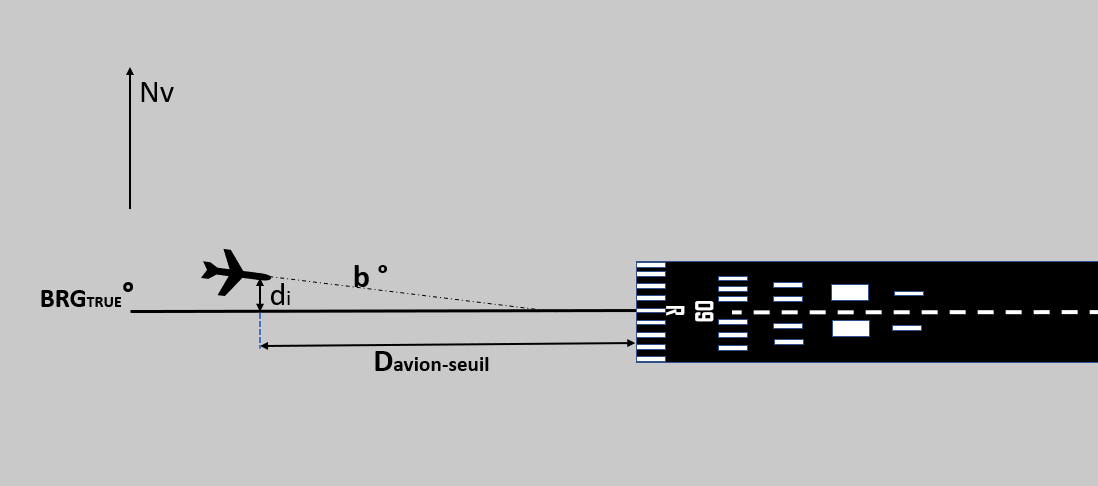

$$\bar d=\frac{1}{N}\sum_{i=1}^{N} d_i$$

$$\sigma=\sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(d_i-\bar d)^2}$$

$$Id5_{écart}=\frac{\frac{1}{N}\sum_{i=1}^{N} |d_i|}{L/2}\times100$$

$$Id5_{instabilité}=\frac{σ}{L/2}\times100$$

L = , la largeur de l'aire de protection de l'approche finale au niveau du Localizer.

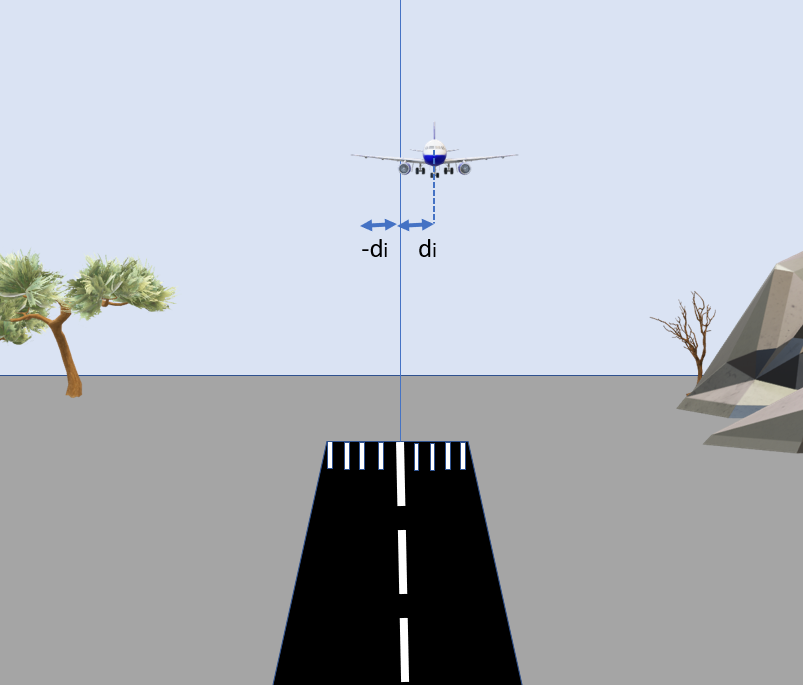

D'après le DOC 8168, la demi-largeur de l'aire de protection au niveau du localizer est de 150 m

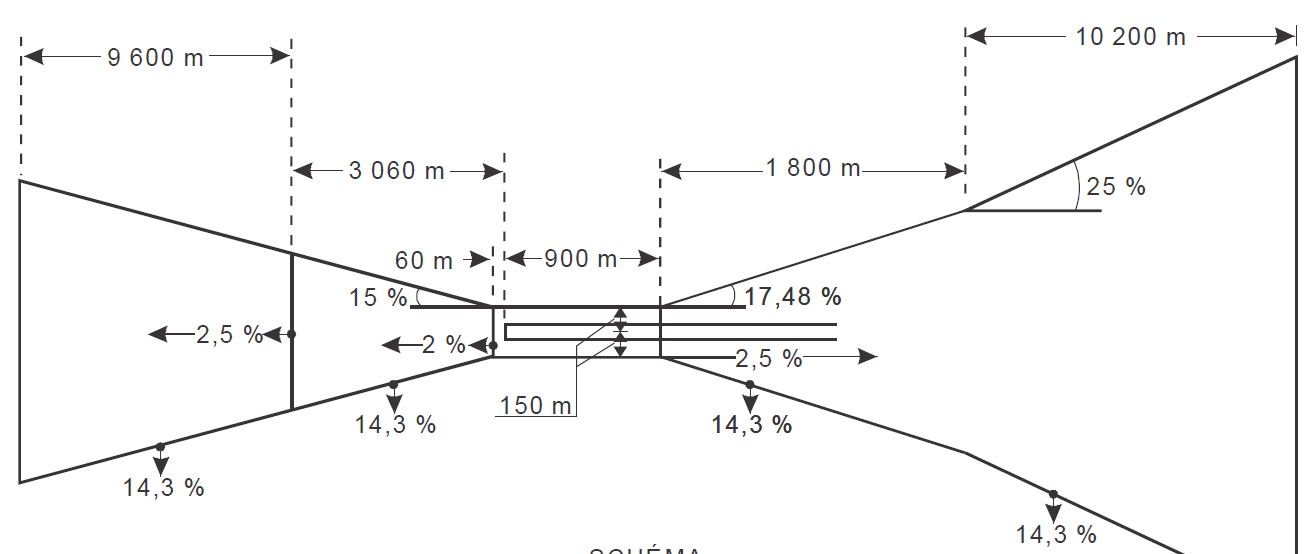

In [89]:
df_app_tma = construire_df_app(df_tma_general2_net)
df_approach = construire_df_app(df_approach_net)
df_app = pd.concat([df_approach, df_app_tma], ignore_index=True)

In [90]:
df_final_tma = construire_df_final(df_tma_general2_net)
df_final09 = construire_df_final(df_approach_net)
df_final = pd.concat([df_final09, df_final_tma], ignore_index=True)

Seuils d'interpretation de $Id5_{écart}$ :

* 0 à 5 % : très bien aligné (écart ≤ 1,1 m)
* 5 à 10 % : bien aligné (1,1 m à 2,25 m)
* 10 à 20 % : alignement acceptable (2,25 m à 4,5 m)
* 20 à 50 % : décalé (4,5 m à 11,25 m)
* 50 à 100 % : fortement décalé (11,25 m à 22,5 m)
* supérieur à 100 % : hors bord de piste (> 22,5 m)

Seuils d'interpretation de $Id5_{instabilité}$ :

* 0 à 10 % : stable
* 10 à 20 % : assez stable
* 20 à 40 % : instable
* supérieur à 40 % : très instable

**Id5 de l'IAF au seuil 09R**

In [91]:
id5_app = id5_alignement(df_app)
afficher_html("Coefficient de variation Id5 sur l'approche (IAF/IF ➡ THR 09R)",style ='sous_titre')
Id5_app = ajouter_tolerance(id5_app, "Id5")
Id5_app

,Date,Heure_arrivee,icao24,Callsign,Ecart_moy_m,Id5_ecart (%),Interpretation_ecart,Sigma_m,Id5_instabilite (%),Interpretation_instabilite,Tol_ecart (%),Tol_instabilite (%)
0,2026-04-07,16:51:59,3f1a389d,ETH937,3.90,17.50,Alignement acceptable,3.30,14.80,Assez stable,42.23265,42.23265
1,2026-04-10,01:08:28,3f2562c0,RAM547P,7.90,35.10,Décalé,4.30,19.20,Assez stable,42.23265,42.23265
2,2026-04-10,04:27:59,3f2592ee,THY635,5.90,26.30,Décalé,3.80,17.00,Assez stable,42.23265,42.23265
5,2026-04-10,09:28:58,3f273928,SKK047,10.80,47.80,Décalé,18.50,82.20,Très instable,42.23265,42.23265
7,2026-04-10,10:44:29,3f2766d0,ETH936,4.20,18.60,Alignement acceptable,2.40,10.70,Assez stable,42.23265,42.23265
4,2026-04-10,12:31:29,3f2728bd,IAM1423,10.80,47.90,Décalé,14.20,63.10,Très instable,42.23265,42.23265
3,2026-04-10,12:39:28,3f270a79,ETH937,6.00,26.70,Décalé,5.20,23.10,Instable,42.23265,42.23265
6,2026-04-10,12:55:59,3f2753ae,OYA5070,8.40,37.50,Décalé,10.60,47.10,Très instable,42.23265,42.23265
9,2026-04-10,15:29:29,3f284e26,SKK046,11.60,51.30,Fortement décalé,19.50,86.70,Très instable,42.23265,42.23265
8,2026-04-10,19:15:29,3f27f235,THY522,4.00,17.60,Alignement acceptable,2.10,9.50,Stable,42.23265,42.23265


**Id5 sur segment d'approche finale**

In [92]:
id5_final = id5_alignement(df_final)
afficher_html("Coefficient de variation Id5 en final 09R (FAF/FAP ➡ THR 09R)",style ='sous_titre')
Id5_final = ajouter_tolerance(id5_final, "Id5")
Id5_final

,Date,Heure_arrivee,icao24,Callsign,Ecart_moy_m,Id5_ecart (%),Interpretation_ecart,Sigma_m,Id5_instabilite (%),Interpretation_instabilite,Tol_ecart (%),Tol_instabilite (%)
0,2026-04-07,16:51:59,3f1a389d,ETH937,2.80,12.30,Alignement acceptable,2.20,9.70,Stable,42.23265,42.23265
1,2026-04-10,01:08:28,3f2562c0,RAM547P,4.60,20.40,Décalé,2.80,12.30,Assez stable,42.23265,42.23265
2,2026-04-10,04:27:59,3f2592ee,THY635,5.00,22.40,Décalé,3.60,15.80,Assez stable,42.23265,42.23265
5,2026-04-10,09:28:58,3f273928,SKK047,5.40,23.90,Décalé,4.80,21.20,Instable,42.23265,42.23265
7,2026-04-10,10:44:29,3f2766d0,ETH936,4.20,18.60,Alignement acceptable,2.40,10.70,Assez stable,42.23265,42.23265
4,2026-04-10,12:31:29,3f2728bd,IAM1423,4.80,21.30,Décalé,3.70,16.30,Assez stable,42.23265,42.23265
3,2026-04-10,12:39:28,3f270a79,ETH937,4.00,17.70,Alignement acceptable,2.30,10.20,Assez stable,42.23265,42.23265
6,2026-04-10,12:55:59,3f2753ae,OYA5070,5.10,22.70,Décalé,5.20,23.20,Instable,42.23265,42.23265
9,2026-04-10,15:29:29,3f284e26,SKK046,4.90,21.60,Décalé,5.10,22.50,Instable,42.23265,42.23265
8,2026-04-10,19:15:29,3f27f235,THY522,3.30,14.50,Alignement acceptable,2.00,8.70,Stable,42.23265,42.23265


Trajectoire de SKK046 suffisamment zoomer.

In [93]:
vol = df_app[df_app["callsign"] == "SKK046"].sort_values("timestamp")
m = Map(center=THR09R, zoom=15) #Augmenter le zoom
m.add(Polyline(locations=list(zip(vol["latitude"], vol["longitude"])), weight=2))
m

Map(center=[13.48161, 2.16941], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…

##**Module 13 — Id6. Allongement effectif de la trajectoire en route (KPI 05 GANP)**

 C'est la distance réelle parcourue $D_{réel}$ en route comparée à une distance idéale de référence exprimée en % de distance excédentaire.

Pour notre étude, la distance de référence est calculée le long de la route ATS prévue au plan de vol, en identifiant les waypoints prévus par l’aéronef à l’intérieur de l’UTA de Niamey : $D_{fpl}$.

$D_{réel} = \sum_{k=1}^{n-1}d(A_k,A_{k+1})$ , $A_i$ représentant la $i^{ième}$ position ADS-B observée.

$D_{fpl} =\sum_{k=1}^{n-1}d(P_k,P_{k+1})$ , $d(P_k,P_{k+1})$ étant la distance géodésique entre deux points FPL consécutifs.

$$Id6=\frac{D_{réel}-D_{fpl}}{D_{fpl}}\times 100$$

* $Id6=0%$ : l'avion a suivi exactement la route idéale.

* $Id6>0%$ : trajectoire plus longue.

* $Id6<0%$ : trajectoire plus courte.



> Nous avons choisi 10 vols ayant survolé l'UTA Niamey le 10/04/2026. Ces vols sont choisis de manière à pouvoir obtenir leur plan de vol FPL et leur performance dans la bibliothèque `openAP`.

In [94]:
df_uta_openap = construire_df_uta_openap(df_tma_general2_net,contour_uta,FPL, BILLING) # df des avions en survols ce 10/04/2026

Positions invalides : 0
Altitudes aberrantes : 0
Points conserves : 6,001 (100.0 %)
Filtre bbox    : 31 points écartés
Filtre polygone : 912 points écartés
Points dans UTA : 5058


Choix des 10 vols après avoir exécuté *`df_uta_openap['callsign'].unique()`* donnant la liste de tous les vols.

In [95]:
df_uta_openap['callsign'].unique()

array(['THY9MC', 'ITY853', 'AFR149', 'RAM285', 'ETH907', 'RAM555',
       'RAM587', 'THY635', 'AFR995', 'RAM586', 'RAM284', 'RAM554',
       'UAE9652', 'UAE795', 'THY15', 'ETH909', 'TAP1527', 'AFR940',
       'BEL6ZD', 'AFR722', 'AFR848', 'AFR832', 'KLM589', 'TAR399',
       'RJD234', 'AFR132', 'AFR804', 'THY3KA', 'THY215', 'AFR923',
       'ETH906', 'KLM590'], dtype=object)

In [96]:
liste = ['THY3KA', 'THY215', 'TAP1527', 'RAM554', 'KLM589', 'THY15', 'TAR399', 'UAE9652', 'ETH909','ETH906'] # les 10 vols de l'etude

Les trajectoires des vols sur la carte d'UTA.

>Zoomer la carte en clicant sur (+) suffisamment pour voir les callsigns cachés par d'autres.

In [97]:
Vols = Traffic(df_uta_openap)
trac_trajectoires(Vols, liste , zoom = 7)

Map(center=[14.014987203865275, 0.41698612254090406], controls=(ZoomControl(options=['position', 'zoom_in_text…

Extraction des parties `Texte` de FPL pour les 10 vols.

In [98]:
#La partie Texte des plans de vol FPL du 10/04/2026
FPL['Temps de Création'] = pd.to_datetime(FPL['Temps de Création'])
fpl_10_april = FPL[FPL['Temps de Création'].dt.date == pd.to_datetime('2026-04-10').date()]
FPL_10_avril = fpl_10_april['Texte']

#--------Extraction des 'Texte' des FPL pour les 10 aéronefs choisis ----
extracted_callsigns = FPL_10_avril.str.extract( r"-([^/-]+)(?:/[^-]*)?-", expand=False)
fpl_filtered_by_callsign = FPL_10_avril[extracted_callsigns.isin(liste)]

Récupération des trajectoires des vols depuis `df_uta_openap`.

In [99]:
traj_vols = (df_uta_openap[df_uta_openap["callsign"].isin(liste)]
              .sort_values(["callsign", "timestamp"])
              .reset_index(drop=True))

Trajectoires enrichies par les plans de vol  FPL afin d'avoir `callsign` , `type` et `FPL` ensemble pour l'extraction des waypoints prévus pour les vols.

In [100]:
#---------- Ajouter le plan de vol au dataframe de traj_vols sous la colonne 'Texte_fpl'------------
vols = (traj_vols[["callsign", "type"]].drop_duplicates())

def trouver_fpl(callsign, type):
    fpls = fpl_filtered_by_callsign[fpl_filtered_by_callsign
                                    .str.contains(rf"-{callsign}",case=False,na=False )]
    fpls = fpls[fpls.str.contains(str(type),case=False,na=False)]
    return fpls.iloc[0] if len(fpls) else None

vols["Texte_fpl"] = vols.apply( lambda r: trouver_fpl(r.callsign, r.type),axis=1)

traj_vols_fpl = traj_vols.merge(vols, on=["callsign", "type"], how="left")

Nous allons déterminer les waypoints et navaids dans les limites latérales de l'UTA Niamey définies par `contour_uta`.

In [101]:
#-------------------waypoints dans contour_uta --------------------
wps = navaids.data
poly = SPolygon([(lon, lat) for lat, lon in contour_uta])
navaids_wps_uta = wps[ wps.apply(lambda r: poly
                                 .intersects(Point(r.longitude, r.latitude)),axis=1)]

Liste des waypoints par vols

>Les waypoints et navaids de l’UTA de Niamey ont été extraits automatiquement à partir d’une base de données de navigation aérienne disponibles sur [traffic](https://https://traffic-viz.github.io/data_sources/navigation.html#traffic.data.basic.navaid.Navaids)  fournissant leurs coordonnées géographiques.

Cette approche nous permettra de reconstituer les routes ATS idéales sans saisie manuelle des points de navigation.

In [102]:
#----------- Liste des Waypoints des avions contenus dans la bibliothèque traffic ---
wps_uta = set(navaids_wps_uta["name"].str.upper())
for cs, texte in (traj_vols_fpl[["callsign", "Texte_fpl"]].drop_duplicates().dropna().values):

    mots = re.findall(r"\b[A-Z0-9]{2,10}\b", texte.upper())
    wp_trouves = [m for m in mots if m in wps_uta]

    print(f"Waypoints/navaids de {cs} : {wp_trouves}")
    print("_" * 50)

Waypoints/navaids de ETH906 : ['NY']
__________________________________________________
Waypoints/navaids de ETH909 : ['BOVDA', 'NEMLO', 'LIPET']
__________________________________________________
Waypoints/navaids de KLM589 : ['ABALA', 'IPUTA']
__________________________________________________
Waypoints/navaids de RAM554 : ['IKRIT']
__________________________________________________
Waypoints/navaids de TAP1527 : ['ABALA', 'IPUTA']
__________________________________________________
Waypoints/navaids de TAR399 : ['DAMNA']
__________________________________________________
Waypoints/navaids de THY15 : ['DAMNA', 'NY']
__________________________________________________
Waypoints/navaids de THY215 : ['DAMNA', 'NY']
__________________________________________________
Waypoints/navaids de THY3KA : ['NY', 'DAMNA']
__________________________________________________
Waypoints/navaids de UAE9652 : ['NY']
__________________________________________________


>Certains waypoints, bien que mentionnés sur le plan de vol des avions ne figurent pas sur la carte de radionavigation de l'ASECNA.

###13.1 Calcul de $D_{fpl}$ et $D_{réal}$

Pour chaque vol, nous avons:

*ENTREE_UTA ➡ wpts/Nvd 1 ➡ ... ➡ wpts/Nvd n ➡ SORTIE_UTA*

In [103]:
# -------------- Dataframe Route plan de vol --------
routes_fpl = construire_route_fpl(traj_vols_fpl, navaids_wps_uta)
#-------------------Différentes distances -----------------------------
d_fpl = calcul_dfpl(routes_fpl)       # FPL
d_real = calcul_dreal(traj_vols)      # REELLE

###13.2 Détermination de $Id6$




In [104]:
df_id6 = (d_fpl.merge(d_real, on="callsign"))
df_id6["Id5 (%)"] = ((df_id6["D_REEL_nm"] - df_id6["D_FPL_nm"])/ df_id6["D_FPL_nm"]* 100)#.round(0)
df_id6 = ajouter_tolerance(df_id6, "Id6")
display(df_id6)

,callsign,D_FPL_nm,D_REEL_nm,Id5 (%),Tol_Id6 (%)
0,ETH906,322.76,322.76,-0.00,0.00159
1,ETH909,350.86,295.20,-15.87,0.00146
2,KLM589,344.58,311.76,-9.53,0.00149
3,RAM554,239.88,235.19,-1.95,0.00214
4,TAP1527,333.85,324.94,-2.67,0.00154
5,TAR399,366.81,357.91,-2.42,0.00140
6,THY15,341.03,329.32,-3.43,0.00150
7,THY215,330.65,328.02,-0.80,0.00155
8,THY3KA,353.91,345.89,-2.27,0.00145
9,UAE9652,348.55,284.87,-18.27,0.00147


In [105]:
Id6_global = (df_id6["D_REEL_nm"].sum() - df_id6["D_FPL_nm"].sum())/ df_id6["D_FPL_nm"].sum()* 100
afficher_html(f"Id6 global = {Id6_global:.2f} %", style='sous_titre')

> **Sur ces 10 vols, nous remarquons un gain en distance de 5,91 % démontrant l'apport du guidage radar dans l'économie de carburant aux compagnies aériennes**.









###13.3 Visualisation route FPL vs route réelle

In [106]:
mFPL = routes_fpl.query('callsign=="ETH909"').sort_values("ordre")
mADSB = traj_vols.query('callsign=="ETH909"').sort_values("timestamp")

m = Map(center=(mADSB.latitude.mean(), mADSB.longitude.mean()), zoom=7)

m.add(Polyline(locations=list(zip(mADSB.latitude, mADSB.longitude)), color="blue", fill=False))
m.add(Polyline(locations=list(zip(mFPL.latitude, mFPL.longitude)), color="orange", fill=False))

for _, r in mFPL.iterrows():
    p = CircleMarker(location=(r.latitude, r.longitude), radius=5, color="red", fill_color="red")
    p.popup = Popup(location=(r.latitude, r.longitude), child=HTML(r.point))
    m.add(p)

m.add(Polyline(locations=contour_uta, color="green", weight=5, fill=False))

Map(center=[np.float64(12.995999358974357), np.float64(1.662512820512821)], controls=(ZoomControl(options=['po…

## **Module 14 — Id7. Consommation additionnelle de carburant (KPI 16 GANP)**

L'Id7 traduit en carburant l'écart de distance mesuré à l'Id6 entre la
route réellement empruntée et la route du plan de vol déposé.

Nous allons nous servir d'`OpenAP` qui est un modèle sur les  performances des aéronefs (Sun et al., 2020) pour estimer la consommation carburant.

Le modèle ne calcule pas directement la consommation totale. Il estime d'abord le débit instantané de carburant (Fuel Flow), puis intègre ce débit sur l'ensemble de la trajectoire. A un instant i on a,
$$FF_i = f(m_i, TAS_i, Alt_i)$$

* $FF_i$ : débit de carburant (kg/s)

* $m_i$ : masse de l'aéronef (kg)

* $TAS_i$ : vitesse vraie (True Air Speed) (kt)

* $Alt_i$ : altitude (ft)


> La bibliothèque OpenAP requiert la masse instantanée de l'aéronef pour estimer le débit carburant. En l'absence de données de masse réelles, nous allons considérer que la masse des avions à l'entrée de l'UTA est à 85% de sa MTOW (tout comme dans Openap). $$m_0 = 0,85 × MTOW$$ La masse est mise à jour après chaque intervalle temporel :

$$m_i=m_{i-1}-Fuel_{i-1}$$




In [107]:
Mtows = construire_df_mtow(traj_vols) # Extraction de la MTOW des avions
df_calc = traj_vols.merge(Mtows[["callsign", "MTOW_kg"]],on="callsign", how="left").rename(columns={
    "gspeed": "groundspeed",
    "vspeed": "vertical_rate",
    "Type": "typecode"})

In [108]:
df_calc.head()

,icao24,latitude,longitude,track,altitude,groundspeed,vertical_rate,squawk,timestamp,source,flight,callsign,hex,type,reg,painted_as,operating_as,orig_iata,orig_icao,dest_iata,dest_icao,eta,query_timestamp_utc,_source,Callsign,typecode,MTOW_kg
0,3f29ef85,13.23,-0.99,85,39000,527,0,1371,2026-04-10 22:54:29+00:00,ADSB,ET906,ETH906,040124,B788,ET-ATH,ETH,ETH,BKO,GABS,ADD,HAAB,2026-04-11T04:07:28Z,2026-04-10 22:54:30+00:00,TMA_GENERALE_2026-04-10_tranche16sur16.csv,ETH906,B788,228000
1,3f29ef85,13.24,-0.91,85,38975,527,0,1371,2026-04-10 22:54:58+00:00,ADSB,ET906,ETH906,040124,B788,ET-ATH,ETH,ETH,BKO,GABS,ADD,HAAB,2026-04-11T04:07:28Z,2026-04-10 22:55:00+00:00,TMA_GENERALE_2026-04-10_tranche16sur16.csv,ETH906,B788,228000
2,3f29ef85,13.24,-0.84,85,38975,526,0,1371,2026-04-10 22:55:29+00:00,ADSB,ET906,ETH906,040124,B788,ET-ATH,ETH,ETH,BKO,GABS,ADD,HAAB,2026-04-11T04:05:20Z,2026-04-10 22:55:30+00:00,TMA_GENERALE_2026-04-10_tranche16sur16.csv,ETH906,B788,228000
3,3f29ef85,13.25,-0.76,85,39000,527,-64,1371,2026-04-10 22:55:58+00:00,ADSB,ET906,ETH906,040124,B788,ET-ATH,ETH,ETH,BKO,GABS,ADD,HAAB,2026-04-11T04:03:12Z,2026-04-10 22:56:00+00:00,TMA_GENERALE_2026-04-10_tranche16sur16.csv,ETH906,B788,228000
4,3f29ef85,13.26,-0.69,85,38975,526,0,1371,2026-04-10 22:56:28+00:00,ADSB,ET906,ETH906,040124,B788,ET-ATH,ETH,ETH,BKO,GABS,ADD,HAAB,2026-04-11T04:03:12Z,2026-04-10 22:56:30+00:00,TMA_GENERALE_2026-04-10_tranche16sur16.csv,ETH906,B788,228000


Nous allons calculer le débit moyen sur la route réelle.
$$FF_{nm}=\frac{Fuel_{reel}}{D_{reel}}$$

$$Id7 = (D_{reel}-D_{fpl})× FF_{nm}$$

In [109]:
resultats = []
for callsign, vol in df_calc.groupby("callsign"):
    vol = vol.sort_values("timestamp").copy()
    vol["timestamp"] = pd.to_datetime(vol["timestamp"])
    vol["dt"] = vol["timestamp"].diff().dt.total_seconds().fillna(0)
    masse = 0.85 * vol["MTOW_kg"].iloc[0]

    ff_model = FuelFlow(vol["typecode"].iloc[0],use_synonym=True)

    #Intégration sur le trajet
    fuel_total = 0.0
    for _, row in vol.iterrows():
        ff = float(ff_model.enroute( mass=masse, tas=row["groundspeed"],
                                    alt=row["altitude"],vs=row["vertical_rate"])) #Modèle de calcul du Fuelflow
        fuel = ff * row["dt"] # FF_i
        fuel_total += fuel
        masse -= fuel # Mise à jour de la masse
    resultats.append({"callsign": callsign,"typecode": vol["typecode"].iloc[0],"fuel_kg": round(fuel_total, 1)})
df_fuel = pd.DataFrame(resultats)

/usr/local/lib/python3.12/dist-packages/openap/drag.py:72: UserWarning:

Drag polar: using synonym a20n for a21n



In [110]:
df_id7 = (df_id6[["callsign","D_FPL_nm","D_REEL_nm","Id5 (%)"]]
          .merge(df_fuel[["callsign","typecode","fuel_kg"]], on="callsign"))

df_id7["FF_nm"] = df_id7["fuel_kg"] / df_id7["D_REEL_nm"]
df_id7["Id6_kg"] = df_id7["FF_nm"] * (df_id7["D_REEL_nm"] - df_id7["D_FPL_nm"])

df_id7 = ajouter_tolerance(df_id7, "Id7")

df_id7 = df_id7[["callsign","typecode","fuel_kg","FF_nm","Id6_kg","Tol_kg"]].round(2)
afficher_html("Consommation additionnelle de carburant (KPI 16 GANP)",style ='sous_titre')
display(df_id7)

,callsign,typecode,fuel_kg,FF_nm,Id6_kg,Tol_kg
0,ETH906,B788,3234.90,10.02,-0.02,0.05142
1,ETH909,B788,3105.50,10.52,-585.61,0.05493
2,KLM589,B77W,7809.60,25.05,-822.19,0.12924
3,RAM554,B788,2375.00,10.10,-47.35,0.05182
4,TAP1527,A21N,1432.00,4.41,-39.24,0.02262
5,TAR399,A20N,1260.10,3.52,-31.30,0.01807
6,THY15,A359,5355.00,16.26,-190.45,0.08348
7,THY215,A359,5348.10,16.30,-42.96,0.08366
8,THY3KA,B38M,1645.60,4.76,-38.19,0.02442
9,UAE9652,B77W,6653.90,23.36,-1487.31,0.12280


In [111]:
Id7_global = df_id7["Id6_kg"].sum()
afficher_html(f"Id6 global = {Id7_global:.2f} kg", style='sous_titre')

> **Le guidage radar aura permi d'economiser  3284.62 kg de carburant sur 10 vols dans une journée.**



## **Module 15 — Id8. Émissions de CO₂ sous guidage radar Vs sans guidage radar**

Les émissions de CO₂ sont estimées selon le modèle de CORSIA (*Carbon Offsetting and Reduction Scheme for International Aviation*), OACI, 2024.

Le facteur d'émission CO₂ est :  **CO₂_factor = 3.16** pour le Jet A-1 ➡ 1 kg de carburant brûlé = 3.16 kg de CO₂ émi.

Id8 n'est rien d'autre que l'emission CO₂ équivalant carburant additionnel calculé en Id7 étant donné que la route idéale considérée pour nos calculs de Id6 et Id7 est la route du plan de vol.

$$Id8_{kgCO2}​=Id7_{kg}​×3.16$$




In [112]:
df_id8 = df_id7.copy()
df_id8["Id7_kgCO2"] = (df_id8["Id6_kg"]*FACTEUR_CO2)
df_id8["CO2_guidage_radar(kg)"] = (df_id8["fuel_kg"] * FACTEUR_CO2)
df_id8["CO2_sans_guidage_radar(kg)"] = ((df_id8["fuel_kg"] - df_id8["Id6_kg"]) * FACTEUR_CO2)
df_id8 = ajouter_tolerance(df_id8, "Id8")
df_id8 = df_id8[["callsign", "typecode","CO2_sans_guidage_radar(kg)","CO2_guidage_radar(kg)","Id7_kgCO2","Tol_kgCO2"]].round(2)
display(df_id8)

,callsign,typecode,CO2_sans_guidage_radar(kg),CO2_guidage_radar(kg),Id7_kgCO2,Tol_kgCO2
0,ETH906,B788,10222.35,10222.28,-0.06,0.16249
1,ETH909,B788,11663.91,9813.38,-1850.53,0.17358
2,KLM589,B77W,27276.46,24678.34,-2598.12,0.40840
3,RAM554,B788,7654.63,7505.00,-149.63,0.16375
4,TAP1527,A21N,4649.12,4525.12,-124.00,0.07148
5,TAR399,A20N,4080.82,3981.92,-98.91,0.05710
6,THY15,A359,17523.62,16921.80,-601.82,0.26380
7,THY215,A359,17035.75,16900.00,-135.75,0.26437
8,THY3KA,B38M,5320.78,5200.10,-120.68,0.07717
9,UAE9652,B77W,25726.22,21026.32,-4699.90,0.38805


In [113]:
id8_global = df_id8["Id7_kgCO2"].sum()
afficher_html(f"Id7 global = {id8_global:.2f} kg de CO2", style='sous_titre')

La mise en oeuvre du guidage radar dans l'UTA Niamey permet de reduire les émissions CO2 de **10379.40 kg** sur 10 survols d'une journée.